# 마스터셋 탐색 및 전처리

In [23]:
import pandas as pd

# 1. 데이터 불러오기
file_path = "master_dataset_final.csv"
df = pd.read_csv(file_path)

# 2. 기본 정보 확인
print("### 데이터 정보 ###")
df.info()

# 3. 데이터 샘플 확인
print("\n### 데이터 샘플 (상위 5개) ###")
print(df.head())

# 4. 클래스 분포 확인 (가장 중요!)
print("\n### 피싱 여부(is_phishing) 클래스 분포 ###")
print(df["is_phishing"].value_counts())

### 데이터 정보 ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_id        12000 non-null  object
 1   text           12000 non-null  object
 2   phishing_type  6000 non-null   object
 3   is_phishing    12000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 375.1+ KB

### 데이터 샘플 (상위 5개) ###
         file_id                                               text  \
0    normal_2408  아 그럼 알겠습니다. 그러면 지금 바로 환불 접수 도와드릴까요? 에 좀 해주시겠어요...   
1    normal_0867  네 네 감사합니다. 예. o/입금일은 이번 주 금요일 오후 (6시)/(여섯 시) 이...   
2  phishing_2722  안녕하세요, OOO님. 국민연금관리공단의 정입니다. 네, 어떤 일이세요? '납부 내...   
3  phishing_1239  역과 국민계좌가 시중에서 새로 개술이 됐습니다. 네. 뭐 아시는 부분이라도 전혀 없...   
4    normal_0475  o/ 네. 장바구니 들어가시면은요n/. 거기 오른쪽 하단에 재 결제라는 버튼 보이시...   

  phishing_type  is_phishing  
0           NaN            0  
1           NaN            0  
2         기관사칭형        

In [24]:
import re


# 간단한 텍스트 정제 함수 (필요에 따라 규칙 추가)
def clean_text(text):
    # 의미 없는 특수문자나 기호 제거
    text = re.sub(
        r"[^\w\s<>]", "", text
    )  # 영문, 숫자, 한글, 공백, <, > 제외하고 모두 제거
    return text


# 정제 함수 적용
def clean_text_simple(text):
    # 영문, 숫자, 한글, 공백, 그리고 마스킹 토큰을 위한 <, > 기호를 제외한
    # 모든 특수문자를 공백으로 바꿔주는 규칙
    text = re.sub(r"[^\w\s<>]", " ", text)

    # 여러 개의 공백을 하나로 합치고 양쪽 끝 공백 제거
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['cleaned_text'] = df['text'].apply(clean_text_simple)


# 클래스별로 텍스트 데이터 분리
phishing_texts = df[df["is_phishing"] == 1]["cleaned_text"].tolist()
normal_texts = df[df["is_phishing"] == 0]["cleaned_text"].tolist()

print(f"\n피싱 대화 개수: {len(phishing_texts)}개")
print(f"정상 대화 개수: {len(normal_texts)}개")


피싱 대화 개수: 6000개
정상 대화 개수: 6000개


In [25]:
from kiwipiepy import Kiwi
from collections import Counter

kiwi = Kiwi()


# 단어 빈도 분석 함수
def get_word_counts(texts):
    word_counts = Counter()
    for text in texts:
        # 형태소 분석 (명사, 동사, 형용사 위주로 추출)
        tokens = [
            token.form
            for token in kiwi.tokenize(text)
            if token.tag in ["NNG", "NNP", "VV", "VA"]
        ]
        word_counts.update(tokens)
    return word_counts


# 각 클래스별 단어 빈도 계산
phishing_word_counts = get_word_counts(phishing_texts)
normal_word_counts = get_word_counts(normal_texts)

print("\n### 피싱 대화 상위 20개 단어 ###")
print(phishing_word_counts.most_common(20))

print("\n### 정상 대화 상위 20개 단어 ###")
print(normal_word_counts.most_common(20))


### 피싱 대화 상위 20개 단어 ###
[('있', 25456), ('하', 24989), ('되', 21335), ('확인', 14358), ('드리', 13670), ('본인', 12162), ('말씀', 11294), ('계좌', 11130), ('없', 11110), ('고객', 10947), ('알', 9394), ('통장', 8404), ('맞', 8300), ('연락', 7340), ('같', 6878), ('전화', 6639), ('은행', 6540), ('진행', 6205), ('사건', 5945), ('정보', 5245)]

### 정상 대화 상위 20개 단어 ###
[('하', 48365), ('되', 44237), ('있', 24672), ('확인', 21490), ('드리', 13588), ('교재', 13235), ('감사', 13015), ('회원', 12052), ('같', 11817), ('말씀', 11311), ('환불', 10392), ('알', 10134), ('없', 8257), ('결제', 7948), ('가능', 7756), ('맞', 7273), ('전화', 6544), ('취소', 6227), ('주', 6087), ('그러', 5995)]


# 워드클라우드로 불용어 목록으로 뺄 단어 찾아보기

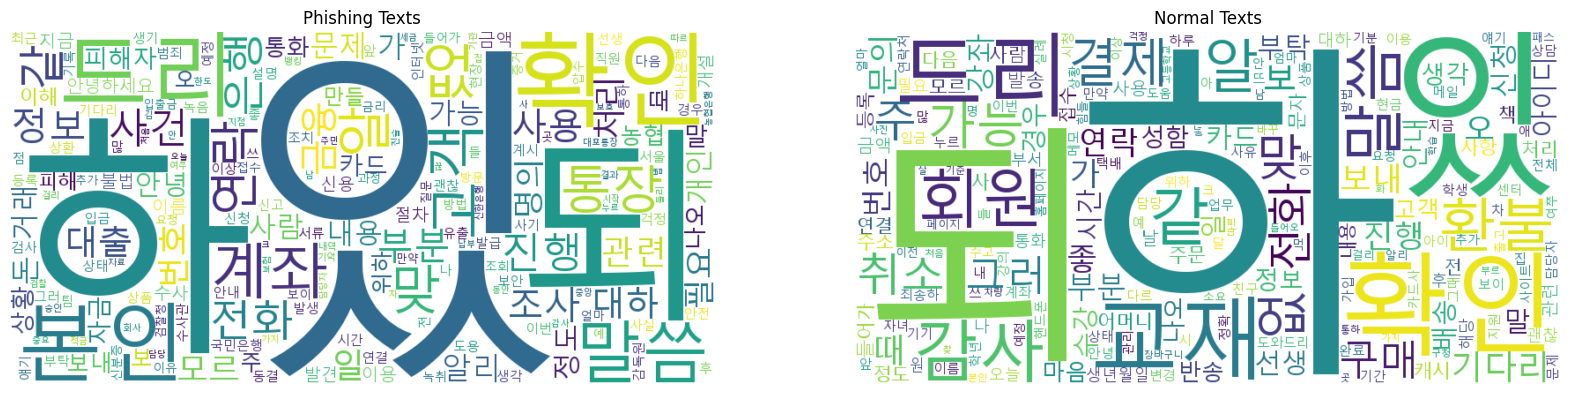

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# (폰트 경로 설정 필요)
font_path = "C:/Windows/Fonts/malgun.ttf"

# 피싱 워드 클라우드 생성
wc_phishing = WordCloud(
    font_path=font_path, background_color="white", width=800, height=400
).generate_from_frequencies(phishing_word_counts)

# 정상 워드 클라우드 생성
wc_normal = WordCloud(
    font_path=font_path, background_color="white", width=800, height=400
).generate_from_frequencies(normal_word_counts)

# 시각화
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wc_phishing, interpolation="bilinear")
plt.title("Phishing Texts")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(wc_normal, interpolation="bilinear")
plt.title("Normal Texts")
plt.axis("off")
plt.show()

# 토큰화 작업 및 TF-IDF, N-gram 벡터화

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from kiwipiepy import Kiwi
import pickle
from scipy.sparse import save_npz, load_npz
from sklearn.model_selection import train_test_split

# --- 1. 재료 준비 ---

# EDA를 통해 얻은 불용어 리스트 (예시)
stop_words = ["하", "있", "되"]

# Kiwi 형태소 분석기 준비 및 사용자 사전 추가
kiwi = Kiwi()
kiwi.add_user_word('대포통장', 'NNP') # '대포통장'을 고유명사로 등록
kiwi.add_user_word('계좌번호', 'NNP')

# --- 2. 우리만의 커스텀 토크나이저 만들기 ---
# TfidfVectorizer가 Kiwi를 사용하도록 연결해주는 함수


def my_kiwi_tokenizer(text):
    # Kiwi를 사용해 텍스트를 형태소로 분리
    tokens = kiwi.tokenize(text)
    # 불용어가 아니고, 우리가 원하는 품사(명사,동사,형용사)만 걸러내기
    return [
        token.form
        for token in tokens
        if token.tag in ["NNG", "NNP", "VV", "VA", "XR"] and token.form not in stop_words
    ]


# --- 3. TfidfVectorizer 설정 및 실행 ---

# TfidfVectorizer 기계 설정
# tokenizer: 우리가 만든 Kiwi 토크나이저 사용
# ngram_range: 1개짜리 단어부터 2개짜리 단어 조합까지 사용
# min_df: 전체 문서에서 최소 5번 이상 등장하는 단어만 사용 (너무 희귀한 단어 제거)
# max_df: 전체 문서의 90% 이상에서 나타나는 단어는 제외 (너무 흔한 단어 제거)
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.95
)


# 데이터 준비 (학습 데이터와 테스트 데이터가 분리되었다고 가정)
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['is_phishing'], test_size=0.2)

# 학습 데이터에 대해 TF-IDF 학습 및 변환 실행
# fit_transform: 단어 사전을 만들고(fit), 텍스트를 숫자 벡터로 변환(transform)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# 테스트 데이터에 대해서는 학습 없이(fit 없이) 변환만 실행
# (학습 데이터로 만든 단어 사전을 그대로 사용해야 하기 때문)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- (여기에 추가!) 어휘집(Vocabulary) 확인 및 CSV 저장 ---

# 1. 학습된 어휘집(단어 목록) 가져오기
# 형태: {'단어1': 인덱스0, '단어2': 인덱스1, ...}
vocabulary = tfidf_vectorizer.vocabulary_

# 2. 보기 좋게 데이터프레임으로 변환
# 인덱스 순서대로 정렬해서 보기 편하게 만듦
vocab_df = (
    pd.DataFrame({"token": vocabulary.keys(), "index": vocabulary.values()})
    .sort_values(by="index")
    .reset_index(drop=True)
)

# 3. CSV 파일로 저장
vocab_df.to_csv("vocabulary.csv", index=False, encoding="utf-8-sig")

print("\n최종 사용된 토큰 목록(어휘집)을 'vocabulary.csv' 파일로 저장했습니다.")
print(f"총 토큰(특징) 개수: {len(vocab_df)}개")
print("### 어휘집 샘플 (상위 10개) ###")
print(vocab_df.head(10))


print(f"TF-IDF 행렬 크기: {X_train_tfidf.shape}")

# ---  학습된 Vectorizer 및 TF-IDF 행렬 저장하기 ---

# Vectorizer 저장 (모델의 '레시피' 저장)
# 나중에 새로운 데이터를 변환할 때 이 파일을 불러와서 똑같은 기준으로 변환해야 함
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

# 생성된 TF-IDF 행렬 저장 (시간 절약을 위해)
# 학습 데이터셋
save_npz("X_train_tfidf.npz", X_train_tfidf)
# 테스트 데이터셋
save_npz("X_test_tfidf.npz", X_test_tfidf)

print("\nVectorizer와 TF-IDF 행렬 저장이 완료되었습니다.")


최종 사용된 토큰 목록(어휘집)을 'vocabulary.csv' 파일로 저장했습니다.
총 토큰(특징) 개수: 41767개
### 어휘집 샘플 (상위 10개) ###
  token  index
0     1      0
1  1 결제      1
2  1 남기      2
3   1 내      3
4  1 말씀      4
5  1 보내      5
6   1 사      6
7  1 안내      7
8   1 없      8
9  1 여쭈      9
TF-IDF 행렬 크기: (9600, 41767)

Vectorizer와 TF-IDF 행렬 저장이 완료되었습니다.


# 로지스틱 회귀 모델 테스트

In [33]:
# --- 1. 필요한 도구들 불러오기 ---

# 모델(학생) 역할을 할 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

# 채점 도구들 (정확도, 정밀도, 재현율, F1 스코어, 혼동 행렬)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.metrics import classification_report  # 결과를 한번에 보여주는 리포트

# --- 2. 모델(학생) 준비 및 학습시키기 ---

# 로지스틱 회귀 모델 객체 생성
# random_state=42 : 실행할 때마다 같은 결과가 나오도록 설정 (재현성)
# class_weight='balanced' : 데이터 불균형을 고려하여 소수 클래스(피싱)에 가중치를 부여
model = LogisticRegression(random_state=42, class_weight="balanced")

# 학습용 데이터(X_train_tfidf)와 정답(y_train)으로 모델을 학습시킴
print("### 모델 학습 시작... ###")
model.fit(X_train_tfidf, y_train)
print("### 모델 학습 완료. ###")


# --- 3. 학습된 모델로 시험(예측) 보기 ---

# 테스트 데이터(X_test_tfidf)에 대한 예측 수행
predictions = model.predict(X_test_tfidf)


# --- 4. 최종 성적표(평가) 출력하기 ---

print("\n--- 최종 모델 성능 평가 ---")

# 각 평가지표 계산
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# 보기 좋게 출력
print(f"정확도 (Accuracy): {accuracy:.4f}")
print(f"정밀도 (Precision): {precision:.4f}")
print(f"*재현율 (Recall): {recall:.4f}*")  # 이 지표가 가장 중요!
print(f"F1 스코어 (F1 Score): {f1:.4f}")

# 혼동 행렬(Confusion Matrix) 출력
# TN | FP
# FN | TP
print("\n### 혼동 행렬 (Confusion Matrix) ###")
conf_matrix = confusion_matrix(y_test, predictions)
print(conf_matrix)

# classification_report를 사용하면 모든 지표를 한번에 볼 수 있음
print("\n### 분류 리포트 (Classification Report) ###")
print(classification_report(y_test, predictions, target_names=["정상(0)", "피싱(1)"]))

### 모델 학습 시작... ###
### 모델 학습 완료. ###

--- 최종 모델 성능 평가 ---
정확도 (Accuracy): 0.9967
정밀도 (Precision): 0.9950
*재현율 (Recall): 0.9983*
F1 스코어 (F1 Score): 0.9966

### 혼동 행렬 (Confusion Matrix) ###
[[1207    6]
 [   2 1185]]

### 분류 리포트 (Classification Report) ###
              precision    recall  f1-score   support

       정상(0)       1.00      1.00      1.00      1213
       피싱(1)       0.99      1.00      1.00      1187

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



# 혼동행렬에서 놓친 것들 텍스트로 뽑아보기

In [34]:
import pandas as pd

# --- (준비) 예측 결과와 실제 정답을 데이터프레임으로 합치기 ---
# 이렇게 해야 원본 텍스트와 함께 보기가 편해

# X_test는 pandas의 Series 형태이므로, 인덱스를 기준으로 합치기 위해 데이터프레임으로 만듦
df_test = pd.DataFrame({"text": X_test, "actual": y_test, "predicted": predictions})


# --- (핵심) 잘못 예측한 경우만 필터링하기 ---

# 1. 피싱(1)인데 -> 정상(0)으로 잘못 예측한 경우 (FN: False Negative)
fn_cases = df_test[(df_test["actual"] == 1) & (df_test["predicted"] == 0)]

# 2. 정상(0)인데 -> 피싱(1)으로 잘못 예측한 경우 (FP: False Positive)
fp_cases = df_test[(df_test["actual"] == 0) & (df_test["predicted"] == 1)]


# --- 결과 출력 ---

print("\n" + "=" * 50)
print("### 모델이 놓친 피싱(FN) 데이터 ###")
print(f"총 {len(fn_cases)} 건")
print("=" * 50)

# 인덱스와 함께 텍스트 내용을 하나씩 출력
for index, row in fn_cases.iterrows():
    print(f"\n[인덱스: {index}]")
    print(row["text"])


print("\n" + "=" * 50)
print("### 모델이 오해한 정상(FP) 데이터 ###")
print(f"총 {len(fp_cases)} 건")
print("=" * 50)

for index, row in fp_cases.iterrows():
    print(f"\n[인덱스: {index}]")
    print(row["text"])


### 모델이 놓친 피싱(FN) 데이터 ###
총 2 건

[인덱스: 155]
진죠 네 그 압트를 사용했던 상품 비연대 상품라고 알시죠 네 어머니 통화하시고 이 간바하게 알고 싶은데 오늘 식사 사를 천하실 거예요 아마 예요 그래서 것이 없기 때문에 없으세요 예 그래서 2부 같은 빨리 계시거나 없으셔야기에 어머니 에 시잖아요 해가지고 이 었군요 아봐 이거 요번에 못 지 아프 새박 거요 예 일단 하고 지면 지금 일 부조건을 안 잡거나 막 있서 어디 위험 다 가고 있기 때에 무 위험 때에 어 시간 앞으금 처리만 저희가 해드릴거구요 어머니 대출받으신 게 있어가지고 네 그렇게 해서 저희가 진행해드릴거고 받아보시까 단 서 단 들어가자세요 일단 뒤신대만 왜냐 어버님 좋가에서 다 안맞추까지 나가 어 받으시다 되실 거고 느 들어갈 필이 없으 현금 네 들어가시 늦렸 아버님도 받으신 있어서 아까 제가 신정해드렸던 건데 보 앞 보러 거요 여 있어가지고 앞전에 내드리는 도가 그냥 지금 고객님 보험 받으시라 말씀을 드린다 예 요번 자금 내드리는 도가 든 건 상환를 하라고 대 확실하게 실 안전하게 확실하게 앞으내 해지된 거 같고 네 자 다신 서 어머니 내고 아니시 어머님 직접 전달해주시고 전달했다 내역 첨만 해주 혹시나 자금을 받고 일 없서 서버 금 올라가고요 예 그래서 혹시나 되시기 전까지는 심사를 받았야 그래서 한국 나 오 들어가시면 차 노 얘야 사실 가 뭐가 나더라 보스 네 친구 주근에 시간 갖고 했 네 학 가섯 거래 하 네 지금이 어떻게냐면 1차 나가요 네 앞전 거는 안되 해가지고 네 어머니 아 주셨잖아요 그까 지금 제가 그걸 설명을 드릴게요 어머니 쪽으로 런거는 받고 들어가신 거고 완아요 이 보 지켜가지고 저 제 자정을 대새더라고 고기들이 어머님도 왔다 다래요 그서 어머니 완자셨잖아요 그니까 를 해드려야 되잖아요 왜 그까 그 지 에서 받은 이가 저희가 보건은 해제라고 덜 사 되시는 거 쓰셔가지고 나머지 자금을 많이 용어 영성 추가 사금이라 고기 상카 하시는 분 권 받는 금액이

# 로지스틱 회귀 K-Fold 검증

In [35]:
# --- 1. K-Fold 교차 검증을 위한 도구 불러오기 ---
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- 2. 모델과 K-Fold 설정 ---
# 로지스틱 회귀 모델 준비
model = LogisticRegression(random_state=42, class_weight="balanced")

# 데이터를 5개로 쪼개서 5번 테스트 (K=5)
# StratifiedKFold: 클래스 비율을 유지하며 데이터를 나눠줌 (불균형 데이터에 좋음)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 테스트의 성능 점수를 저장할 리스트
accuracies, precisions, recalls, f1s = [], [], [], []

print("### 로지스틱 회귀 K-Fold 교차 검증 시작... ###")

# --- 3. K-Fold 교차 검증 실행 ---
# 데이터를 쪼개면서 루프를 돔 (여기서는 전체 데이터를 사용)
# df['cleaned_text']와 df['is_phishing']을 사용
for fold, (train_index, val_index) in enumerate(
    skf.split(df["cleaned_text"], df["is_phishing"])
):
    # 1. 이번 루프에서 사용할 학습/검증 데이터 분리
    X_train_fold, X_val_fold = (
        df["cleaned_text"].iloc[train_index],
        df["cleaned_text"].iloc[val_index],
    )
    y_train_fold, y_val_fold = (
        df["is_phishing"].iloc[train_index],
        df["is_phishing"].iloc[val_index],
    )

    # 2. Vectorizer 학습 및 데이터 변환 (매번 새로 학습)
    tfidf_vectorizer_fold = TfidfVectorizer(
        tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.9
    )
    X_train_tfidf_fold = tfidf_vectorizer_fold.fit_transform(X_train_fold)
    X_val_tfidf_fold = tfidf_vectorizer_fold.transform(X_val_fold)

    # 3. 모델 학습 및 예측
    model.fit(X_train_tfidf_fold, y_train_fold)
    predictions = model.predict(X_val_tfidf_fold)

    # 4. 성능 측정 및 저장
    accuracies.append(accuracy_score(y_val_fold, predictions))
    precisions.append(precision_score(y_val_fold, predictions))
    recalls.append(recall_score(y_val_fold, predictions))
    f1s.append(f1_score(y_val_fold, predictions))

    print(f"Fold {fold+1} 완료 - 재현율: {recalls[-1]:.4f}")

# --- 4. 최종 평균 성능 출력 ---
print("\n--- K-Fold 교차 검증 최종 평균 성능 ---")
print(f"평균 정확도 (Accuracy): {np.mean(accuracies):.4f}")
print(f"평균 정밀도 (Precision): {np.mean(precisions):.4f}")
print(f"**평균 재현율 (Recall): {np.mean(recalls):.4f}**")
print(f"평균 F1 스코어 (F1 Score): {np.mean(f1s):.4f}")

### 로지스틱 회귀 K-Fold 교차 검증 시작... ###


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fold 1 완료 - 재현율: 0.9992


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fold 2 완료 - 재현율: 0.9975


...

Fold 3 완료 - 재현율: 0.9992


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fold 4 완료 - 재현율: 0.9967


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fold 5 완료 - 재현율: 0.9983

--- K-Fold 교차 검증 최종 평균 성능 ---
평균 정확도 (Accuracy): 0.9961
평균 정밀도 (Precision): 0.9940
**평균 재현율 (Recall): 0.9982**
평균 F1 스코어 (F1 Score): 0.9961


In [36]:
import pickle

# --- 1. 학습된 모델 저장하기 ---
# 'logistic_regression_model.pkl' 라는 이름으로 파일을 저장
with open("logistic_regression_model_6000_JJ.pkl", "wb") as f:
    # model 객체를 파일에 저장
    pickle.dump(model, f)

print("로지스틱 회귀 모델이 'logistic_regression_model.pkl' 파일로 저장되었습니다.")


# --- (나중에 불러올 때 사용하는 코드 예시) ---
# with open('logistic_regression_model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)
# print("\n저장된 모델을 성공적으로 불러왔습니다.")

로지스틱 회귀 모델이 'logistic_regression_model.pkl' 파일로 저장되었습니다.


#  부스팅(Boosting) 모델 테스트 (LightGBM), K-Fold
이전 모델의 실수를 보완하는 새로운 모델을 순차적으로 계속 추가

In [37]:
# --- 1. 필요한 모든 도구 불러오기 ---
import time
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from tqdm import tqdm  # 진행률 표시를 위한 tqdm 불러오기

# --- 2. 모델과 K-Fold 설정 ---
lgbm_model_kfold = LGBMClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 평가지표를 저장할 리스트 초기화
accuracies, precisions, recalls, f1s = [], [], [], []
total_conf_matrix = np.zeros((2, 2))  # 혼동 행렬 합계를 위한 초기화

print("### LightGBM K-Fold 교차 검증 시작... ###")
start_time = time.time()  # 시작 시간 기록

# --- 3. K-Fold 교차 검증 실행 (tqdm으로 진행률 표시) ---
for fold, (train_index, val_index) in enumerate(
    tqdm(skf.split(df["cleaned_text"], df["is_phishing"]), total=skf.get_n_splits())
):
    # 데이터 분리
    X_train_fold, X_val_fold = (
        df["cleaned_text"].iloc[train_index],
        df["cleaned_text"].iloc[val_index],
    )
    y_train_fold, y_val_fold = (
        df["is_phishing"].iloc[train_index],
        df["is_phishing"].iloc[val_index],
    )

    # Vectorizer를 루프 안에서 매번 새로 학습
    tfidf_vectorizer_fold = TfidfVectorizer(
        tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.9
    )
    X_train_tfidf_fold = tfidf_vectorizer_fold.fit_transform(X_train_fold)
    X_val_tfidf_fold = tfidf_vectorizer_fold.transform(X_val_fold)

    # 모델 학습 및 예측
    lgbm_model_kfold.fit(X_train_tfidf_fold, y_train_fold)
    predictions = lgbm_model_kfold.predict(X_val_tfidf_fold)

    # 모든 평가지표 계산 및 저장
    accuracies.append(accuracy_score(y_val_fold, predictions))
    precisions.append(precision_score(y_val_fold, predictions))
    recalls.append(recall_score(y_val_fold, predictions))
    f1s.append(f1_score(y_val_fold, predictions))
    total_conf_matrix += confusion_matrix(y_val_fold, predictions)  # 혼동 행렬은 더하기

end_time = time.time()  # 종료 시간 기록
elapsed_time = end_time - start_time  # 총 걸린 시간 계산

# --- 4. 최종 평균 성능 및 소요 시간 출력 ---
print("\n--- LightGBM K-Fold 교차 검증 최종 결과 ---")
print(f"평균 정확도 (Accuracy): {np.mean(accuracies):.4f}")
print(f"평균 정밀도 (Precision): {np.mean(precisions):.4f}")
print(f"**평균 재현율 (Recall): {np.mean(recalls):.4f}**")
print(f"평균 F1 스코어 (F1 Score): {np.mean(f1s):.4f}")
print("\n### 총 혼동 행렬 (Total Confusion Matrix) ###")
print(total_conf_matrix.astype(int))
print(f"\n총 소요 시간: {elapsed_time:.2f} 초")

### LightGBM K-Fold 교차 검증 시작... ###


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 4800, number of negative: 4800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.180294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 280439
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 9579
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
 20%|██        | 1/5 [04:10<16:40, 250.21s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 4800, number of negative: 4800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.169508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 280884
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 9583
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

[LightGBM] [Info] Number of positive: 4800, number of negative: 4800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.256677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 278524
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 9492
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
 80%|████████  | 4/5 [16:56<04:05, 245.38s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 4800, number of negative: 4800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 280415
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 9609
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
100%|██████████| 5/5 [20:38<00:00, 247.76s/it]


--- LightGBM K-Fold 교차 검증 최종 결과 ---
평균 정확도 (Accuracy): 0.9941
평균 정밀도 (Precision): 0.9924
**평균 재현율 (Recall): 0.9958**
평균 F1 스코어 (F1 Score): 0.9941

### 총 혼동 행렬 (Total Confusion Matrix) ###
[[5954   46]
 [  25 5975]]

총 소요 시간: 1238.81 초


In [40]:
import pickle

# --- LightGBM 모델 저장 ---
with open("lightgbm_model.pkl", "wb") as f:
    pickle.dump(lgbm_model_kfold, f)

print("LightGBM 모델이 'lightgbm_model_6000_JJ.pkl' 파일로 저장되었습니다.")

LightGBM 모델이 'lightgbm_model_6000_JJ.pkl' 파일로 저장되었습니다.


# 트리(Tree) 모델 테스트 (Decision Tree), K-Fold
데이터를 '예/아니오' 질문으로 계속 나눠가며 결과 예측

In [38]:
# --- 1. 필요한 모든 도구 불러오기 ---
import time
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from tqdm import tqdm  # 진행률 표시를 위한 tqdm 불러오기

# --- 2. 모델과 K-Fold 설정 ---
tree_model_kfold = DecisionTreeClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 평가지표를 저장할 리스트 초기화
accuracies, precisions, recalls, f1s = [], [], [], []
total_conf_matrix = np.zeros((2, 2))  # 혼동 행렬 합계를 위한 초기화

print("\n### Decision Tree K-Fold 교차 검증 시작... ###")
start_time = time.time()  # 시작 시간 기록

# --- 3. K-Fold 교차 검증 실행 (tqdm으로 진행률 표시) ---
for fold, (train_index, val_index) in enumerate(
    tqdm(skf.split(df["cleaned_text"], df["is_phishing"]), total=skf.get_n_splits())
):
    # 데이터 분리
    X_train_fold, X_val_fold = (
        df["cleaned_text"].iloc[train_index],
        df["cleaned_text"].iloc[val_index],
    )
    y_train_fold, y_val_fold = (
        df["is_phishing"].iloc[train_index],
        df["is_phishing"].iloc[val_index],
    )

    # Vectorizer를 루프 안에서 매번 새로 학습
    tfidf_vectorizer_fold = TfidfVectorizer(
        tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.9
    )
    X_train_tfidf_fold = tfidf_vectorizer_fold.fit_transform(X_train_fold)
    X_val_tfidf_fold = tfidf_vectorizer_fold.transform(X_val_fold)

    # 모델 학습 및 예측
    tree_model_kfold.fit(X_train_tfidf_fold, y_train_fold)
    predictions = tree_model_kfold.predict(X_val_tfidf_fold)

    # 모든 평가지표 계산 및 저장
    accuracies.append(accuracy_score(y_val_fold, predictions))
    precisions.append(precision_score(y_val_fold, predictions))
    recalls.append(recall_score(y_val_fold, predictions))
    f1s.append(f1_score(y_val_fold, predictions))
    total_conf_matrix += confusion_matrix(y_val_fold, predictions)  # 혼동 행렬은 더하기

end_time = time.time()  # 종료 시간 기록
elapsed_time = end_time - start_time  # 총 걸린 시간 계산

# --- 4. 최종 평균 성능 및 소요 시간 출력 ---
print("\n--- Decision Tree K-Fold 교차 검증 최종 결과 ---")
print(f"평균 정확도 (Accuracy): {np.mean(accuracies):.4f}")
print(f"평균 정밀도 (Precision): {np.mean(precisions):.4f}")
print(f"**평균 재현율 (Recall): {np.mean(recalls):.4f}**")
print(f"평균 F1 스코어 (F1 Score): {np.mean(f1s):.4f}")
print("\n### 총 혼동 행렬 (Total Confusion Matrix) ###")
print(total_conf_matrix.astype(int))
print(f"\n총 소요 시간: {elapsed_time:.2f} 초")


### Decision Tree K-Fold 교차 검증 시작... ###


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 20%|██        | 1/5 [03:48<15:13, 228.49s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 40%|████      | 2/5 [07:35<11:22, 227.38s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 60%|██████    | 3/5 [11:21<07:33, 226.91s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 't


--- Decision Tree K-Fold 교차 검증 최종 결과 ---
평균 정확도 (Accuracy): 0.9742
평균 정밀도 (Precision): 0.9750
**평균 재현율 (Recall): 0.9735**
평균 F1 스코어 (F1 Score): 0.9742

### 총 혼동 행렬 (Total Confusion Matrix) ###
[[5850  150]
 [ 159 5841]]

총 소요 시간: 1154.23 초


In [41]:
import pickle

# --- Decision Tree 모델 저장 ---
with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(tree_model_kfold, f)

print("Decision Tree 모델이 'decision_tree_model_6000_JJ.pkl' 파일로 저장되었습니다.")

Decision Tree 모델이 'decision_tree_model_6000_JJ.pkl' 파일로 저장되었습니다.


# 앙상블(Ensemble) 모델 테스트 (Random Forest), K-Fold
 Decision Tree를 수백 개 만들어서 결과를 예측하는 방식

In [39]:
# --- 1. 필요한 모든 도구 불러오기 ---
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from tqdm import tqdm  # 진행률 표시를 위한 tqdm 불러오기

# --- 2. 모델과 K-Fold 설정 ---
rf_model_kfold = RandomForestClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 평가지표를 저장할 리스트 초기화
accuracies, precisions, recalls, f1s = [], [], [], []
# 혼동 행렬을 더하기 위한 2x2 제로 행렬 초기화
total_conf_matrix = np.zeros((2, 2))

print("### RandomForest K-Fold 교차 검증 시작... ###")
start_time = time.time()

# --- 3. K-Fold 교차 검증 실행 (tqdm으로 루프를 감싸서 진행률 표시) ---
for fold, (train_index, val_index) in enumerate(
    tqdm(skf.split(df["cleaned_text"], df["is_phishing"]), total=skf.get_n_splits())
):
    # 데이터 분리
    X_train_fold, X_val_fold = (
        df["cleaned_text"].iloc[train_index],
        df["cleaned_text"].iloc[val_index],
    )
    y_train_fold, y_val_fold = (
        df["is_phishing"].iloc[train_index],
        df["is_phishing"].iloc[val_index],
    )

    # Vectorizer를 루프 안에서 매번 새로 학습
    tfidf_vectorizer_fold = TfidfVectorizer(
        tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.9
    )
    X_train_tfidf_fold = tfidf_vectorizer_fold.fit_transform(X_train_fold)
    X_val_tfidf_fold = tfidf_vectorizer_fold.transform(X_val_fold)

    # 모델 학습 및 예측
    rf_model_kfold.fit(X_train_tfidf_fold, y_train_fold)
    predictions = rf_model_kfold.predict(X_val_tfidf_fold)

    # 모든 평가지표 계산 및 저장
    accuracies.append(accuracy_score(y_val_fold, predictions))
    precisions.append(precision_score(y_val_fold, predictions))
    recalls.append(recall_score(y_val_fold, predictions))
    f1s.append(f1_score(y_val_fold, predictions))
    total_conf_matrix += confusion_matrix(y_val_fold, predictions)  # 혼동 행렬은 더하기

end_time = time.time()
elapsed_time = end_time - start_time

# --- 4. 최종 평균 성능 및 소요 시간 출력 ---
print("\n--- RandomForest K-Fold 교차 검증 최종 결과 ---")
print(f"평균 정확도 (Accuracy): {np.mean(accuracies):.4f}")
print(f"평균 정밀도 (Precision): {np.mean(precisions):.4f}")
print(f"**평균 재현율 (Recall): {np.mean(recalls):.4f}**")
print(f"평균 F1 스코어 (F1 Score): {np.mean(f1s):.4f}")
print("\n### 총 혼동 행렬 (Total Confusion Matrix) ###")
print(total_conf_matrix.astype(int))
print(f"\n총 소요 시간: {elapsed_time:.2f} 초")

### RandomForest K-Fold 교차 검증 시작... ###


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 20%|██        | 1/5 [03:50<15:21, 230.39s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 40%|████      | 2/5 [07:39<11:28, 229.60s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
 60%|██████    | 3/5 [11:28<07:38, 229.31s/it]c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 't


--- RandomForest K-Fold 교차 검증 최종 결과 ---
평균 정확도 (Accuracy): 0.9962
평균 정밀도 (Precision): 0.9952
**평균 재현율 (Recall): 0.9972**
평균 F1 스코어 (F1 Score): 0.9962

### 총 혼동 행렬 (Total Confusion Matrix) ###
[[5971   29]
 [  17 5983]]

총 소요 시간: 1148.80 초


In [42]:
import pickle

# --- Random Forest 모델 저장 ---
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model_kfold, f)

print("Random Forest 모델이 'random_forest_model_6000_JJ.pkl' 파일로 저장되었습니다.")

Random Forest 모델이 'random_forest_model_6000_JJ.pkl' 파일로 저장되었습니다.


# 최종 로지스틱 회귀 학습 후 저장

In [43]:
import pickle
from sklearn.linear_model import LogisticRegression

# --- 2단계: 최종 학습 (Final Training) ---

# 챔피언 모델인 로지스틱 회귀 객체를 다시 생성
final_model = LogisticRegression(random_state=42, class_weight="balanced")

# 전체 학습 데이터를 모두 사용해서 마지막으로 학습시킴
print("### 학습 시작... ###")
final_model.fit(X_train_tfidf, y_train)
print("### 최종 학습 완료. ###")


# --- 3단계: 저장 (Saving) ---

# 최종 학습이 완료된 모델을 파일로 저장
# 이 파일이 바로 나중에 실제 서비스에서 사용될 최종 병기!
with open("final_logistic_regression_model_6000_JJ.pkl", "wb") as f:
    pickle.dump(final_model, f)

print(
    "\n최종 학습된 모델이 'final_logistic_regression_model.pkl' 파일로 저장되었습니다."
)

### 학습 시작... ###
### 최종 학습 완료. ###

최종 학습된 모델이 'final_logistic_regression_model.pkl' 파일로 저장되었습니다.


# 테스트셋 확인

In [ ]:
# -*- coding: utf-8 -*-

# --- 0. 필요한 모든 라이브러리 불러오기 ---
import pandas as pd
import re
import joblib
import pickle
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# --- 1. 텍스트 정제 및 토크나이저 함수 정의 ---
print("정제 및 토크나이저 함수를 정의합니다...")


# 1-1. 텍스트 정제 함수 (네가 사용한 코드)
def clean_text_simple(text):
    text = re.sub(r"[^\w\s<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# 1-2. 사용자 정의 토크나이저 함수
stop_words = ["하", "있", "되"]
kiwi = Kiwi()
kiwi.add_user_word("대포통장", "NNP")
kiwi.add_user_word("계좌번호", "NNP")


def my_kiwi_tokenizer(text):
    tokens = kiwi.tokenize(text)
    return [
        token.form
        for token in tokens
        if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
        and token.form not in stop_words
    ]


print("함수 정의 완료.")


# --- 2. 데이터 불러오기 및 전처리 ---
print("\n전체 데이터를 불러오고 정제합니다...")
try:
    df = pd.read_csv("master_dataset_final.csv")
    print(f"전체 데이터 {len(df)}건을 성공적으로 불러왔습니다.")
except FileNotFoundError:
    print("전체 데이터 파일('master_dataset_final.csv')을 찾을 수 없습니다.")
    exit()

# 2-1. 텍스트 정제 단계 적용
df["cleaned_text"] = df["text"].apply(clean_text_simple)
print("텍스트 정제 완료.")


# --- 3. 데이터 분리 ---
print("\n데이터를 훈련/테스트 세트로 분리합니다...")
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["cleaned_text"],  # 정제된 텍스트를 사용
    df["is_phishing"],
    test_size=0.2,
    random_state=42,
    stratify=df["is_phishing"],
)
print(f"훈련 데이터: {len(y_train)}건, 테스트 데이터: {len(y_test)}건")


# --- 4. TF-IDF Vectorizer 생성, 학습 및 변환 ---
print("\nTF-IDF Vectorizer를 생성하고 데이터에 적용합니다...")
tfidf_vectorizer_6000_JJ = TfidfVectorizer(
    tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.95
)
X_train_vectorized = tfidf_vectorizer_6000_JJ.fit_transform(X_train_text)
X_test_vectorized = tfidf_vectorizer_6000_JJ.transform(X_test_text)
print("Vectorizer 적용 완료.")
print(f"-> 최종 학습된 피처(토큰)의 수: {X_train_vectorized.shape[1]}개")


# --- 5. 로지스틱 회귀 모델 생성 및 학습 ---
print("\n로지스틱 회귀 모델을 생성하고 학습시킵니다...")
model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model.fit(X_train_vectorized, y_train)
print("모델 학습 완료.")


# --- 6. 학습된 모든 결과물 저장하기 ---
print("\n학습된 모든 결과물을 파일로 저장합니다...")
joblib.dump(model, "logistic_model_6000_JJ.joblib")
print("-> 모델이 'logistic_model_6000_JJ.joblib' 파일로 저장되었습니다.")
with open("tfidf_vectorizer_6000_JJ.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
print("-> Vectorizer가 'tfidf_vectorizer_6000_JJ.pkl' 파일로 저장되었습니다.")
y_train.to_csv("y_train_6000_JJ.csv", index=False, header=True)
print("-> 훈련 데이터 라벨이 'y_train_6000_JJ.csv' 파일로 저장되었습니다.")
y_test.to_csv("y_test_6000_JJ.csv", index=False, header=True)
print("-> 테스트 데이터 라벨이 'y_test_6000_JJ.csv' 파일로 저장되었습니다.")

print("\n모든 훈련 및 저장 과정이 완료되었습니다!")

정제 및 토크나이저 함수를 정의합니다...
함수 정의 완료.

전체 데이터를 불러오고 정제합니다...
전체 데이터 12000건을 성공적으로 불러왔습니다.
텍스트 정제 완료.

데이터를 훈련/테스트 세트로 분리합니다...
훈련 데이터: 9600건, 테스트 데이터: 2400건

TF-IDF Vectorizer를 생성하고 데이터에 적용합니다...


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [2]:
# -*- coding: utf-8 -*-

# --- 0. 필요한 모든 라이브러리 불러오기 ---
import pandas as pd
import re
import joblib
import pickle
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import save_npz, load_npz


# --- 1. 텍스트 정제 및 토크나이저 함수 정의 ---
# (이전 코드와 동일)
def clean_text_simple(text):
    text = re.sub(r"[^\w\s<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


stop_words = ["하", "있", "되"]
kiwi = Kiwi()
# ... (사용자 사전 추가 등 동일)


def my_kiwi_tokenizer(text):
    # ... (이전 코드와 동일)
    tokens = kiwi.tokenize(text)
    return [
        token.form
        for token in tokens
        if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
        and token.form not in stop_words
    ]


# --- 2. 훈련 데이터 불러오기 및 전처리 ---
print("훈련 데이터를 불러오고 정제합니다...")
try:
    # '테스트 세트를 제외한' 훈련용 데이터 파일명을 여기에 적어줘
    df_train = pd.read_csv("master_dataset_final.csv")
    print(f"훈련 데이터 {len(df_train)}건을 성공적으로 불러왔습니다.")
except FileNotFoundError:
    print("훈련 데이터 파일을 찾을 수 없습니다.")
    exit()

# 텍스트 정제
df_train["cleaned_text"] = df_train["text"].apply(clean_text_simple)
print("텍스트 정제 완료.")

# 훈련 데이터 전체를 학습에 사용
X_train_text = df_train["cleaned_text"]
y_train = df_train["is_phishing"]

# --- 3. TF-IDF Vectorizer 생성 및 학습/변환 ---
print("\nTF-IDF Vectorizer를 생성하고 데이터에 적용합니다...")
tfidf_vectorizer_6000_JJ = TfidfVectorizer(
    tokenizer=my_kiwi_tokenizer, ngram_range=(1, 2), min_df=5, max_df=0.95
)
X_train_vectorized = tfidf_vectorizer_6000_JJ.fit_transform(X_train_text)
print("Vectorizer 적용 완료.")
print(f"-> 최종 학습된 피처(토큰)의 수: {X_train_vectorized.shape[1]}개")

# --- 4. 로지스틱 회귀 모델 생성 및 학습 ---
print("\n로지스틱 회귀 모델을 생성하고 학습시킵니다...")
model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model.fit(X_train_vectorized, y_train)
print("모델 학습 완료.")

# --- 5. 학습된 모든 결과물 저장하기 ---
print("\n학습된 모든 결과물을 파일로 저장합니다...")

# 5-1. 모델과 Vectorizer 저장
joblib.dump(model, "logistic_model_6000_JJ.joblib")
print("-> 모델이 'logistic_model_6000_JJ.joblib' 파일로 저장되었습니다.")
with open("tfidf_vectorizer_6000_JJ.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer_6000_JJ, f)
print("-> Vectorizer가 'tfidf_vectorizer_6000_JJ.pkl' 파일로 저장되었습니다.")

# 5-2. X (피처) 데이터 저장
# 훈련 데이터의 피처(X) 저장
save_npz("X_train_vectorized_6000_JJ.npz", X_train_vectorized)
print(
    "-> 훈련 데이터 피처(X)가 'X_train_vectorized_6000_JJ.npz' 파일로 저장되었습니다."
)


# 5-3. y 라벨(정답) 저장
y_train.to_csv("y_train_6000_JJ.csv", index=False, header=True)
print("-> 훈련 데이터 라벨(y)이 'y_train_6000_JJ.csv' 파일로 저장되었습니다.")

print("\n모든 훈련 및 저장 과정이 완료되었습니다!")

훈련 데이터를 불러오고 정제합니다...
훈련 데이터 12000건을 성공적으로 불러왔습니다.
텍스트 정제 완료.

TF-IDF Vectorizer를 생성하고 데이터에 적용합니다...


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vectorizer 적용 완료.
-> 최종 학습된 피처(토큰)의 수: 52327개

로지스틱 회귀 모델을 생성하고 학습시킵니다...
모델 학습 완료.

학습된 모든 결과물을 파일로 저장합니다...
-> 모델이 'logistic_model_6000_JJ.joblib' 파일로 저장되었습니다.
-> Vectorizer가 'tfidf_vectorizer_6000_JJ.pkl' 파일로 저장되었습니다.
-> 훈련 데이터 피처(X)가 'X_train_vectorized_6000_JJ.npz' 파일로 저장되었습니다.
-> 훈련 데이터 라벨(y)이 'y_train_6000_JJ.csv' 파일로 저장되었습니다.

모든 훈련 및 저장 과정이 완료되었습니다!


In [3]:
import pandas as pd
import pickle

# --- 1. 변환할 CSV 파일 이름 지정 ---
csv_file_name = "y_train_6000_JJ.csv"
pickle_file_name = "y_train_6000_JJ.pkl"

# --- 2. CSV 파일 불러오기 ---
print(f"'{csv_file_name}' 파일을 불러옵니다...")
try:
    # CSV 파일을 판다스 데이터프레임(또는 시리즈)으로 읽어들임
    y_train_data = pd.read_csv(csv_file_name)

    # 만약 y 라벨이 단일 열이라면, 시리즈 형태로 바꿔주는 것이 더 정확함
    # CSV에 열이 하나만 있다면, 그 열의 이름을 여기에 적어줘. (예: 'is_phishing')
    # 보통 header=True로 저장했으면 첫 번째 열 이름이 자동으로 들어감
    if len(y_train_data.columns) == 1:
        y_train_series = y_train_data[y_train_data.columns[0]]
        print("CSV 파일을 성공적으로 불러와 시리즈(Series) 형태로 변환했습니다.")
    else:
        y_train_series = y_train_data  # 열이 여러 개면 그냥 데이터프레임으로 둠
        print("CSV 파일을 성공적으로 불러왔습니다.")

except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: '{csv_file_name}'")
    exit()

# --- 3. Pickle 파일로 저장하기 ---
print(f"\n데이터를 '{pickle_file_name}' 파일로 저장합니다...")
with open(pickle_file_name, "wb") as f:
    # 불러온 판다스 시리즈 객체를 그대로 픽클로 저장
    pickle.dump(y_train_series, f)

print("변환 및 저장이 완료되었습니다!")

'y_train_6000_JJ.csv' 파일을 불러옵니다...
CSV 파일을 성공적으로 불러와 시리즈(Series) 형태로 변환했습니다.

데이터를 'y_train_6000_JJ.pkl' 파일로 저장합니다...
변환 및 저장이 완료되었습니다!


In [7]:
# --- 0. 필요한 라이브러리 모두 불러오기 ---
# (이전과 동일)
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi

# ... (모든 sklearn import)


# --- 1. 토크나이저 클래스 정의 (최종 완성본) ---
class KiwiTokenizer:
    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    # 포장/해제 설명서 추가 (핵심 해결책)
    def __getstate__(self):
        # 저장할 때 호출됨. state에서 'kiwi' 객체를 제외함.
        state = self.__dict__.copy()
        del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 불러올 때 호출됨. state를 복원하고 'kiwi'는 None으로 초기화.
        self.__dict__.update(state)
        self.kiwi = None


# --- 2. 데이터 불러오기 ---
# (이전과 동일)
print("데이터를 불러옵니다...")
df = pd.read_csv("master_dataset_final.csv")
X = df["text"].astype(str)
y = df["is_phishing"]
print(f"총 {len(df)}개의 데이터 로드 완료.")

# --- 3. 모델 및 파이프라인 구성 ---
# (이전과 동일)
print("\n스태킹 모델을 구성합니다...")
base_models = [
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=42
        ),
    ),
]
meta_model = LogisticRegression(max_iter=1000, random_state=42)
stacked_clf = StackingClassifier(
    estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1
)

print("\n전체 파이프라인을 생성합니다...")
pipeline_stacking = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                tokenizer=KiwiTokenizer(),
                sublinear_tf=True,
                min_df=5,
                max_df=0.9,
                ngram_range=(1, 2),
            ),
        ),
        ("clf", stacked_clf),
    ]
)
print("파이프라인 생성 완료.")

# --- 4. K-Fold 교차 검증 및 평가 ---
# (이전과 동일)
print("\nK-Fold 교차 검증을 시작합니다 (시간이 다소 소요될 수 있습니다)...")
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_stack = cross_val_predict(pipeline_stacking, X, y, cv=skf, n_jobs=-1)
print("교차 검증 완료.")
print("\n--- [스태킹 모델 최종 성능 리포트] ---")
print(classification_report(y, y_pred_stack, target_names=["정상대화", "보이스피싱"]))
print("------------------------------------")

# --- 5. 최종 모델 학습 및 저장 ---
# (이전과 동일)
print("\n전체 데이터로 최종 모델을 학습하고 저장합니다...")
pipeline_stacking.fit(X, y)
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(
    pipeline_stacking, os.path.join(model_dir, "stacking_model_pipeline_6000_JJ.pkl")
)
print(
    f"최종 모델이 '{model_dir}/stacking_model_pipeline_6000_JJ.pkl' 파일로 저장되었습니다."
)

데이터를 불러옵니다...
총 12000개의 데이터 로드 완료.

스태킹 모델을 구성합니다...

전체 파이프라인을 생성합니다...
파이프라인 생성 완료.

K-Fold 교차 검증을 시작합니다 (시간이 다소 소요될 수 있습니다)...
교차 검증 완료.

--- [스태킹 모델 최종 성능 리포트] ---
              precision    recall  f1-score   support

        정상대화       1.00      1.00      1.00      6000
       보이스피싱       1.00      1.00      1.00      6000

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000

------------------------------------

전체 데이터로 최종 모델을 학습하고 저장합니다...


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


최종 모델이 'models/stacking_model_pipeline_6000_JJ.pkl' 파일로 저장되었습니다.


# 테스트셋 저장된 모델로 분류해보기

In [16]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호가 깨지는 문제 해결
plt.rcParams["axes.unicode_minus"] = False

class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        # 각 프로세스에서 최초 호출 시 Kiwi 객체를 한 번만 생성
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        # 텍스트 정제
        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        # 형태소 분석 및 필터링
        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 최종 클래스 정의 완료.")

초기 설정 및 최종 클래스 정의 완료.


In [17]:
# --- 1. 파일 경로 및 모델 로딩 ---
print("저장된 스태킹 모델 파이프라인을 불러옵니다...")

pipeline_path = os.path.join("models", "stacking_model_pipeline_6000_JJ.pkl")

try:
    loaded_pipeline = joblib.load(pipeline_path)
    print(f"모델 로드 완료: {pipeline_path}")
except Exception as e:
    print(f"모델 로딩 중 에러 발생: {e}")

저장된 스태킹 모델 파이프라인을 불러옵니다...
모델 로드 완료: models\stacking_model_pipeline_6000_JJ.pkl



############################################################
'1차모델_테스트데이터셋.csv' 파일에 대한 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 506건
 - 보이스피싱 (1) 예측: 494건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       0.99      1.00      0.99       500
       보이스피싱       1.00      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



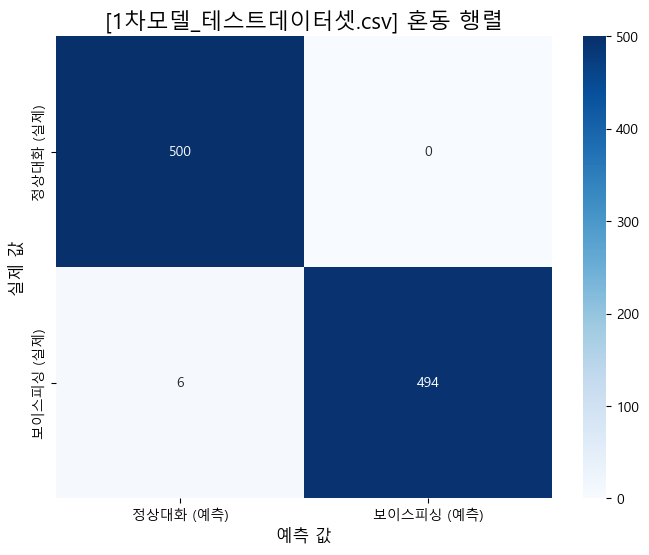


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,예 고객님 담당자 김성도 대리입니다.예지금 법무사님이 두분 배정되셨어요.네 네네 네...,1,1,98.09
1,6시 되가지고 전화 해봤습니다.예 예 그 앞전에 이면주 법무사님 영수증 확인되셨는데...,1,1,98.56
2,네 네 네 여보세요네 네어디에 계시는 겁니까 지금네?지금 어디 계시는 거예요방금 나...,1,1,99.89
3,여보세요예 여보세요. 네 감사과장 박철민 과장입니다.예아 OOO고객님 맞으시죠?예아...,1,1,99.87
4,신한은행 정부지원자금으로 마이너스 통장 계좌 통합 가능하십니다. 마이너스 통장 발급...,1,1,99.30
5,보니까 서면조사를 받으셔야 되고요 알겠습니다 그럼 말씀 드릴게요 계속 말씀드렸다시피...,1,1,99.26
6,서울중앙지검네 예 다름이 아니라 접수가 돼서 연락을 드렸고요. 예 통화 괜찮으신가요...,1,1,99.75
7,빨리 오세요 여기 강남청솔기숙 거예요 강남스타일 가요 가요 이제 신고 접수 확인 다...,1,1,73.59
8,예 예 아이고 통화해 보셨어요 님 아닌데요 어떤 것들이 님 저 지금 그쪽 확인해서 ...,1,1,98.86
9,네 고객님 아 근데 제가 보니까 같은데요. 우리은행 시간 많이 심어 놨습니다. 연락...,1,1,98.91


############################################################

############################################################
'시나리오통화테스트셋.csv' 파일에 대한 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 7건
 - 보이스피싱 (1) 예측: 13건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       1.00      0.70      0.82        10
       보이스피싱       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



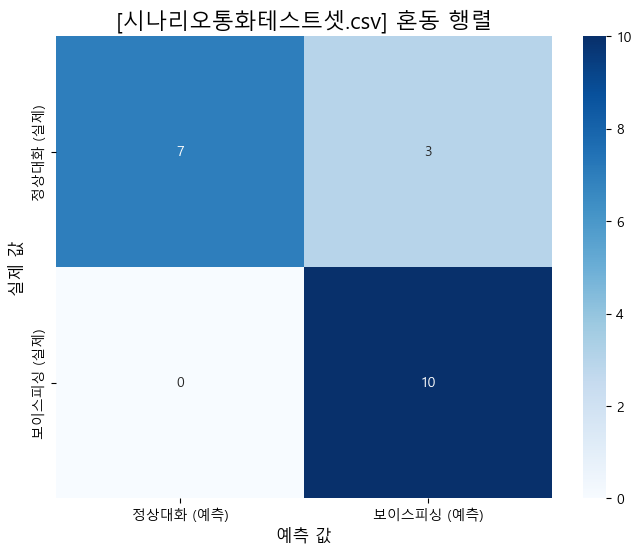


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,"네, 여보세요.\n네, 여보세요. 서울지방경찰청 사이퍼 범죄추사팀 박민선 승사관입니...",1,1,99.91
1,"고객님, 안녕하세요. 농협캐피탈입니다.\n고객님은 신용등급 상향 대상자로 선정되셔서...",1,1,99.80
2,"여보세요? 엄마 나야 나 지금 핸드폰 애 저 깨졌어, 친구 폰으로 연락했어.\n누구...",1,1,99.26
3,"네, 여보세요, 고객님, 안녕하세요, 로젠택배입니다, 고객님. 택배가 주소 의류로 ...",1,1,99.55
4,"네, 안녕하세요. 국민건강보험공단입니다. 고객님.\n작년 과오납 환급금이 47만원 ...",1,1,99.84
5,"네, 여보세요.\n네, 안녕하세요. 국민은행 상담센터입니다. 무엇을 도와드릴까요?\...",0,1,98.62
6,"엄마, 나 또 액정이 깨졌어, 지금 친구 폰으로 전화했어.\n더 깨졌어, 핸드폰을 ...",0,1,96.04
7,어제 주문한 물건이 계속 배송 중으로만 떠있어서요.\n운송장 번호 확인 가능하실까요...,0,0,4.40
8,세종내과입니다. 무엇을 도와드릴까요?\n혹시 그다음 주 수요일쯤 진료 예약 가능할까...,0,0,9.47
9,"안녕하세요. KB 국민카드 고객센터입니다. 무엇을 도와드릴까요?\n아니, 이번 달 ...",0,1,76.63


############################################################


In [18]:
# --- 2. 예측, 평가, 결과 출력 함수 정의 ---
def predict_and_display_results(csv_path: str, pipeline):
    """
    주어진 CSV 파일을 읽어 피싱 여부를 예측하고,
    정답지가 있을 경우 성능 평가까지 수행하는 함수.
    """
    print("\n" + "#" * 60)
    print(f"'{csv_path}' 파일에 대한 분석을 시작합니다.")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: '{csv_path}'")
        return

    if "text" not in df.columns:
        print(f"'{csv_path}' 파일에 'text' 열이 없습니다.")
        return

    X_new = df["text"].astype(str)

    # 예측 수행
    predictions = pipeline.predict(X_new)
    probabilities = pipeline.predict_proba(X_new)

    # 예측 결과를 데이터프레임에 추가
    df["predicted_label"] = predictions
    df["phishing_probability"] = probabilities[:, 1] * 100

    # 예측 결과 요약 출력
    print("\n[ 예측 결과 요약 ]")
    prediction_counts = df["predicted_label"].value_counts()
    print(f" - 정상 대화 (0) 예측: {prediction_counts.get(0, 0)}건")
    print(f" - 보이스피싱 (1) 예측: {prediction_counts.get(1, 0)}건")

    # 성능 평가 로직 추가
    # 'is_phishing' 정답 열이 있을 경우에만 평가 수행
    if "is_phishing" in df.columns:
        y_true = df["is_phishing"]

        print("\n--- [ 모델 성능 평가 리포트 ] ---")
        # Classification Report 출력 (정밀도, 재현율, f1-score)
        print(
            classification_report(
                y_true, predictions, target_names=["정상대화", "보이스피싱"]
            )
        )

        # 혼동 행렬 (Confusion Matrix) 시각화
        cm = confusion_matrix(y_true, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["정상대화 (예측)", "보이스피싱 (예측)"],
            yticklabels=["정상대화 (실제)", "보이스피싱 (실제)"],
        )
        plt.title(f"[{csv_path}] 혼동 행렬", fontsize=16)
        plt.ylabel("실제 값", fontsize=12)
        plt.xlabel("예측 값", fontsize=12)
        plt.show()  # 그래프 보여주기
    else:
        print("\n[알림] 정답(is_phishing) 열이 없어 성능 평가는 생략합니다.")

    print("\n[ 예측 결과 샘플 (상위 10개) ]")
    display_columns = ["text", "predicted_label", "phishing_probability"]
    if "is_phishing" in df.columns:
        display_columns.insert(1, "is_phishing")

    pd.options.display.float_format = "{:,.2f}".format
    display(df[display_columns].head(10))
    print("#" * 60)


# --- 3. 테스트할 파일 목록에 대해 분석 실행 ---
files_to_test = ["1차모델_테스트데이터셋.csv", "시나리오통화테스트셋.csv"]

for file_path in files_to_test:
    predict_and_display_results(file_path, loaded_pipeline)

# 보류구간 찾기

In [19]:
# [사전 준비 코드] - 훈련 스크립트의 5번 단계에 추가/수정

from sklearn.model_selection import StratifiedKFold, cross_val_predict

print("\nK-Fold 교차 검증으로 예측 확률을 계산합니다...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# method='predict_proba'로 설정해서 확률값을 얻어냄
y_probas = cross_val_predict(
    pipeline_stacking, X, y, cv=skf, n_jobs=-1, method="predict_proba"
)

# 피싱일 확률(클래스 1의 확률)만 따로 저장
y_probas_phishing = y_probas[:, 1]

print("예측 확률 계산 완료.")


K-Fold 교차 검증으로 예측 확률을 계산합니다...
예측 확률 계산 완료.


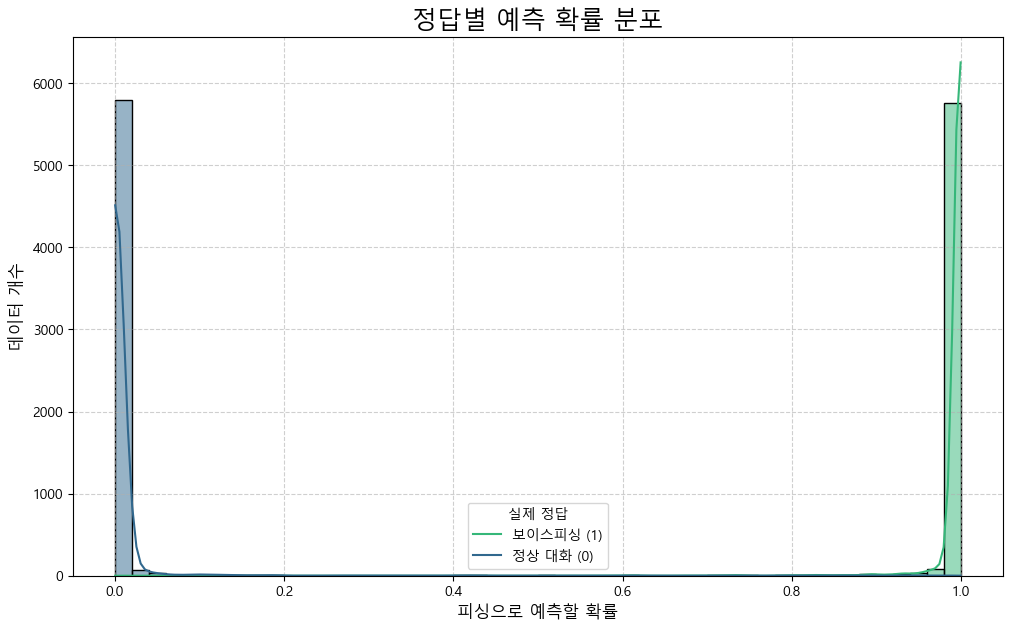

In [20]:
# [방법 1: 시각화 코드]

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 분석을 위해 데이터프레임으로 합치기
results_df = pd.DataFrame({"true_label": y, "probability": y_probas_phishing})

plt.figure(figsize=(12, 7))
# hue='true_label' : 실제 정답에 따라 색을 다르게 표현
# kde=True : 확률 밀도 곡선을 함께 그려줌
sns.histplot(
    data=results_df,
    x="probability",
    hue="true_label",
    bins=50,
    kde=True,
    palette="viridis",
)

plt.title("정답별 예측 확률 분포", fontsize=18)
plt.xlabel("피싱으로 예측할 확률", fontsize=12)
plt.ylabel("데이터 개수", fontsize=12)
plt.legend(title="실제 정답", labels=["보이스피싱 (1)", "정상 대화 (0)"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

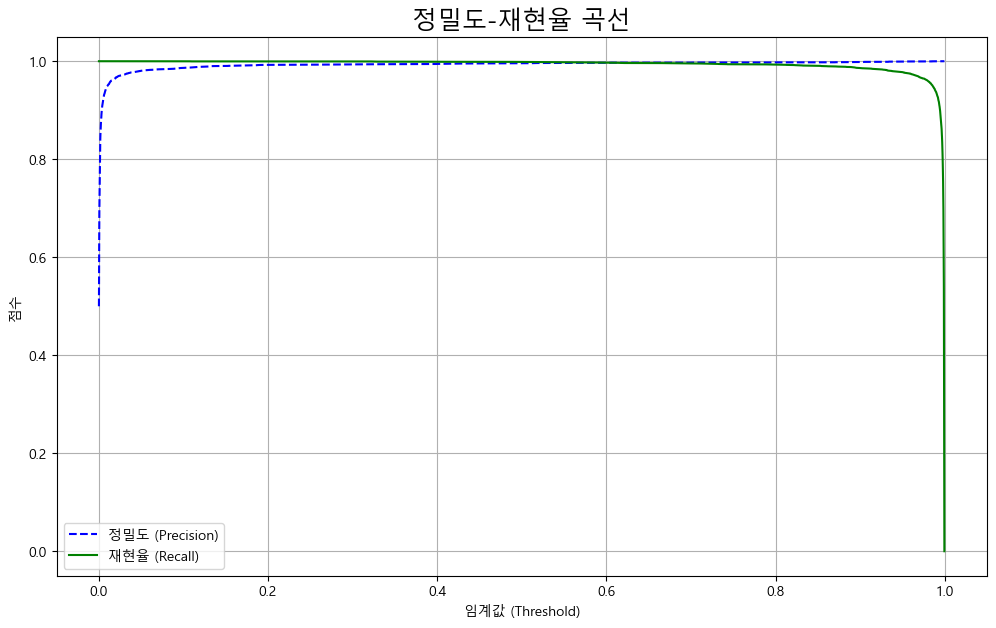

재현율 98%를 만족하는 최소 임계값 (하위 임계값 후보): 0.0004
정밀도 98%를 만족하는 최소 임계값 (상위 임계값 후보): 0.0489


In [21]:
# [방법 2: P-R 곡선 코드]

from sklearn.metrics import precision_recall_curve

# P-R 곡선에 필요한 값들 계산
precisions, recalls, thresholds = precision_recall_curve(y, y_probas_phishing)

# 그래프 그리기
plt.figure(figsize=(12, 7))
plt.plot(thresholds, precisions[:-1], "b--", label="정밀도 (Precision)")
plt.plot(thresholds, recalls[:-1], "g-", label="재현율 (Recall)")
plt.xlabel("임계값 (Threshold)")
plt.ylabel("점수")
plt.title("정밀도-재현율 곡선", fontsize=18)
plt.grid(True)
plt.legend()
plt.show()

# 예시: 재현율이 98% 이상인 지점의 최소 임계값 찾기 -> 하위 임계값 후보
idx_for_recall_98 = np.argmax(recalls >= 0.98)
lower_threshold_candidate = thresholds[idx_for_recall_98]
print(
    f"재현율 98%를 만족하는 최소 임계값 (하위 임계값 후보): {lower_threshold_candidate:.4f}"
)

# 예시: 정밀도가 98% 이상인 지점의 최소 임계값 찾기 -> 상위 임계값 후보
idx_for_precision_98 = np.argmax(precisions >= 0.98)
upper_threshold_candidate = thresholds[idx_for_precision_98]
print(
    f"정밀도 98%를 만족하는 최소 임계값 (상위 임계값 후보): {upper_threshold_candidate:.4f}"
)

In [23]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm  # 진행 상황을 보여주는 라이브러리


#  KiwiTokenizer 클래스 정의는 필수 (이전 코드와 동일, 생략)
class KiwiTokenizer:
    """
    scikit-learn 파이프라인 및 병렬 처리 환경에서 안전하게 사용하기 위한
    Kiwi 토크나이저 클래스 (저장/로드 문제 완벽 해결 버전).
    """

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


# --- 1. 모델 로딩 및 예측 확률 미리 계산하기 ---
print("모델을 불러오고 예측 확률을 미리 계산합니다...")

# 저장된 파이프라인 파일 경로
pipeline_path = "models/stacking_model_pipeline_6000_JJ.pkl"
# 원본 데이터 파일 경로
data_path = "master_dataset_final.csv"

# 모델 로드
loaded_pipeline = joblib.load(pipeline_path)
# 데이터 로드
df = pd.read_csv(data_path)
X = df["text"].astype(str)
y = df["is_phishing"]

# 교차 검증으로 예측 확률과 일반 예측값을 한 번에 얻어두기
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probas = cross_val_predict(
    loaded_pipeline, X, y, cv=skf, n_jobs=-1, method="predict_proba"
)
y_preds_original = cross_val_predict(
    loaded_pipeline, X, y, cv=skf, n_jobs=-1
)  # 메트릭 계산용

# 피싱일 확률(클래스 1)만 추출
y_probas_phishing = y_probas[:, 1]
print("예측 확률 계산 완료.")


# --- 2. 임계값 탐색(Grid Search) 시작 ---
print("\n최적 임계값 탐색을 시작합니다 (시간이 소요될 수 있습니다)...")

# 테스트할 임계값 범위 설정
# 예: 0.05부터 0.5까지 0.05씩 증가 (하위 임계값 후보)
low_thresholds = np.arange(0.05, 0.51, 0.05)
# 예: 0.5부터 0.95까지 0.05씩 증가 (상위 임계값 후보)
high_thresholds = np.arange(0.5, 1.0, 0.05)

results = []  # 결과를 저장할 리스트

# tqdm을 사용해 진행 상황을 시각적으로 표시
for low in tqdm(low_thresholds, desc="Lower Threshold"):
    for high in high_thresholds:
        # 하위 임계값이 상위 임계값보다 크거나 같으면 의미 없으므로 건너뛰기
        if low >= high:
            continue

        # 보류 구간 적용 (-1: 보류, 0: 정상, 1: 피싱)
        conditions = [(y_probas_phishing < low), (y_probas_phishing > high)]
        choices = [0, 1]
        final_preds = np.select(conditions, choices, default=-1)

        # 보류되지 않은 데이터만 선택하기 위한 마스크
        coverage_mask = final_preds != -1

        # 처리율(Coverage) 계산
        coverage = np.mean(coverage_mask)

        # 보류되지 않은 데이터가 하나도 없으면 성능 계산 불가
        if coverage == 0:
            continue

        # 보류되지 않은 데이터에 대한 성능 지표 계산
        f1 = f1_score(y[coverage_mask], y_preds_original[coverage_mask])
        precision = precision_score(y[coverage_mask], y_preds_original[coverage_mask])
        recall = recall_score(y[coverage_mask], y_preds_original[coverage_mask])

        # 결과 저장
        results.append(
            {
                "low": round(low, 2),
                "high": round(high, 2),
                "f1": f1,
                "precision": precision,
                "recall": recall,
                "coverage": coverage,
            }
        )

print("임계값 탐색 완료.")

# --- 3. 결과 저장 및 출력 ---
# 결과를 데이터프레임으로 변환
results_df = pd.DataFrame(results)

# 성능이 좋은 순으로 정렬 (recall, f1 내림차순, coverage 내림차순)
results_df = results_df.sort_values(
    by=["recall", "f1", "coverage"], ascending=[False, False, False]
)

# CSV 파일로 저장
output_csv_path = "rejection_optimization_results_6000_JJ.csv"
results_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"\n 최적화 결과가 '{output_csv_path}' 파일로 저장되었습니다.")
print("\n--- [상위 10개 최적 임계값 조합] ---")
print(results_df.head(10))

모델을 불러오고 예측 확률을 미리 계산합니다...
예측 확률 계산 완료.

최적 임계값 탐색을 시작합니다 (시간이 소요될 수 있습니다)...


Lower Threshold: 100%|██████████| 10/10 [00:00<00:00, 12.25it/s]

임계값 탐색 완료.

 최적화 결과가 'rejection_optimization_results_6000_JJ.csv' 파일로 저장되었습니다.

--- [상위 10개 최적 임계값 조합] ---
    low  high   f1  precision  recall  coverage
10 0.10  0.50 1.00       1.00    1.00      0.99
0  0.05  0.50 1.00       1.00    1.00      0.99
11 0.10  0.55 1.00       1.00    1.00      0.99
1  0.05  0.55 1.00       1.00    1.00      0.99
12 0.10  0.60 1.00       1.00    1.00      0.99
2  0.05  0.60 1.00       1.00    1.00      0.99
13 0.10  0.65 1.00       1.00    1.00      0.99
3  0.05  0.65 1.00       1.00    1.00      0.99
14 0.10  0.70 1.00       1.00    1.00      0.99
4  0.05  0.70 1.00       1.00    1.00      0.99


# 2차 모델용 피처 설정을 위한 코드

In [24]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import numpy as np
import re
from typing import List
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, mutual_info_classif


class KiwiTokenizer:
    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되", "없"]  # 불용어 추가

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            # 사용자 사전은 필요에 따라 추가
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens


# --- 1. 데이터 로딩 및 준비 ---
print("데이터를 불러옵니다...")
try:
    df = pd.read_csv("master_dataset_final.csv")
    # 'text'와 'phishing_type' 열 이름이 맞는지 확인. 다르면 수정 필요.
    df = df.dropna(subset=["text", "phishing_type"])  # 혹시 모를 결측치 제거
    print(f"총 {len(df)}개의 데이터 로드 완료.")
except FileNotFoundError:
    print("master_dataset_final.csv 파일을 찾을 수 없습니다.")
    exit()

# --- 2. 텍스트 데이터 벡터화 ---
# 통계 기반 분석에는 TF-IDF보다 단어 빈도(Count)가 더 적합
print("\n텍스트 데이터를 단어 빈도 행렬로 변환합니다...")
vectorizer = CountVectorizer(
    tokenizer=KiwiTokenizer(), min_df=5
)  # 최소 5번 이상 등장한 단어만
X_counts = vectorizer.fit_transform(df["text"].astype(str))
# 전체 단어 목록 (어휘집)
vocab = np.array(vectorizer.get_feature_names_out())
print(f"총 {len(vocab)}개의 고유한 토큰으로 벡터화 완료.")

# --- 3. 유형별 키워드 추출 ---
# 데이터에 있는 모든 피싱 유형 가져오기
phishing_types = df["phishing_type"].unique()
print(f"\n분석할 피싱 유형: {phishing_types}")

# 각 유형별 결과를 저장할 딕셔너리
keyword_results = {}

for p_type in phishing_types:
    print("\n" + "=" * 50)
    print(f"'{p_type}' 유형의 핵심 키워드를 추출합니다...")

    # 3-1. One-vs-Rest를 위한 이진 타겟(y) 생성
    # 현재 유형은 1, 나머지는 모두 0
    y_binary = (df["phishing_type"] == p_type).astype(int)

    # 3-2. 카이제곱 및 상호 정보량 점수 계산
    chi2_scores, _ = chi2(X_counts, y_binary)
    mi_scores = mutual_info_classif(X_counts, y_binary, random_state=42)

    # 3-3. 점수와 키워드를 묶어 데이터프레임 생성
    result_df = pd.DataFrame({"keyword": vocab, "chi2": chi2_scores, "mi": mi_scores})

    keyword_results[p_type] = result_df

# --- 4. 결과 출력 ---
N_TOP_KEYWORDS = 20  # 각 유형별로 상위 몇 개 키워드를 볼지 설정

for p_type, result_df in keyword_results.items():
    print("\n" + "#" * 60)
    print(f"             '{p_type}' 유형 핵심 키워드 Top {N_TOP_KEYWORDS} ")
    print("#" * 60)

    # 카이제곱 점수 기준 상위 키워드
    top_chi2 = result_df.sort_values(by="chi2", ascending=False).head(N_TOP_KEYWORDS)
    print("\n--- [카이제곱 (Chi-Squared) 기준] ---")
    print(top_chi2[["keyword", "chi2"]].to_string(index=False))

    # 상호 정보량 점수 기준 상위 키워드
    top_mi = result_df.sort_values(by="mi", ascending=False).head(N_TOP_KEYWORDS)
    print("\n--- [상호 정보량 (Mutual Information) 기준] ---")
    print(top_mi[["keyword", "mi"]].to_string(index=False))

데이터를 불러옵니다...
총 6000개의 데이터 로드 완료.

텍스트 데이터를 단어 빈도 행렬로 변환합니다...


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


총 3921개의 고유한 토큰으로 벡터화 완료.

분석할 피싱 유형: ['기관사칭형' '메신저피싱형' '대출빙자형' '가족지인사칭형' '투자권유형' '택배사칭형' '콜백스미싱형']

'기관사칭형' 유형의 핵심 키워드를 추출합니다...

'메신저피싱형' 유형의 핵심 키워드를 추출합니다...

'대출빙자형' 유형의 핵심 키워드를 추출합니다...

'가족지인사칭형' 유형의 핵심 키워드를 추출합니다...

'투자권유형' 유형의 핵심 키워드를 추출합니다...

'택배사칭형' 유형의 핵심 키워드를 추출합니다...

'콜백스미싱형' 유형의 핵심 키워드를 추출합니다...

############################################################
             '기관사칭형' 유형 핵심 키워드 Top 20 
############################################################

--- [카이제곱 (Chi-Squared) 기준] ---
keyword     chi2
     본인 6,725.93
     계좌 4,436.34
     사건 4,099.18
     통장 3,783.58
     조사 3,261.02
     확인 2,381.26
     고객 2,282.14
     말씀 2,045.27
    피해자 1,958.97
     명의 1,918.36
     금융 1,879.99
     대출 1,818.79
     수사 1,676.84
     피해 1,597.03
     모르 1,564.81
     사용 1,403.43
      알 1,369.17
     불법 1,279.65
     만들 1,273.32
     관련 1,250.89

--- [상호 정보량 (Mutual Information) 기준] ---
keyword   mi
     대출 0.09
     사건 0.09
     조사 0.09
     범죄 0.09
     계좌 0.07
     본인 0.07
 

In [26]:
print("\n분석 결과를 유형별 CSV 파일로 저장합니다...")

# 결과를 저장할 폴더 생성 (선택 사항)
output_dir = "keyword_results"
os.makedirs(output_dir, exist_ok=True)

# 각 피싱 유형별로 반복
for p_type, result_df in keyword_results.items():

    # 유형 이름을 포함한 파일 경로 생성
    # 예: "keyword_results/keywords_대출빙자형.csv"
    output_csv_path = os.path.join(output_dir, f"keywords_{p_type}.csv")

    print(f"-> '{p_type}' 유형의 키워드를 '{output_csv_path}' 파일로 저장 중...")

    # chi2 점수가 높은 순으로 정렬
    sorted_df = result_df.sort_values(by="chi2", ascending=False)

    # CSV 파일로 저장
    # index=False: 불필요한 인덱스 번호가 저장되지 않도록 함
    # encoding='utf-8-sig': 엑셀에서 한글이 깨지지 않게 하기 위함
    sorted_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"\n모든 키워드 분석 결과가 '{output_dir}' 폴더에 CSV 파일로 저장되었습니다.")


분석 결과를 유형별 CSV 파일로 저장합니다...
-> '기관사칭형' 유형의 키워드를 'keyword_results\keywords_기관사칭형.csv' 파일로 저장 중...
-> '메신저피싱형' 유형의 키워드를 'keyword_results\keywords_메신저피싱형.csv' 파일로 저장 중...
-> '대출빙자형' 유형의 키워드를 'keyword_results\keywords_대출빙자형.csv' 파일로 저장 중...
-> '가족지인사칭형' 유형의 키워드를 'keyword_results\keywords_가족지인사칭형.csv' 파일로 저장 중...
-> '투자권유형' 유형의 키워드를 'keyword_results\keywords_투자권유형.csv' 파일로 저장 중...
-> '택배사칭형' 유형의 키워드를 'keyword_results\keywords_택배사칭형.csv' 파일로 저장 중...
-> '콜백스미싱형' 유형의 키워드를 'keyword_results\keywords_콜백스미싱형.csv' 파일로 저장 중...

모든 키워드 분석 결과가 'keyword_results' 폴더에 CSV 파일로 저장되었습니다.


# 저장된 다른 모델들 같은벡터라이저로 학습

In [ ]:
# --- 0. 필요한 라이브러리 및 데이터/Vectorizer 로딩 ---
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# KiwiTokenizer 클래스 정의
class KiwiTokenizer:
    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens


# 데이터 불러오기 (df 변수에 데이터가 로드되어 있다고 가정)
df = pd.read_csv("master_dataset_final.csv")

print("저장된 Vectorizer를 불러옵니다...")
try:
    # 1. 저장된 Vectorizer를 먼저 불러온다
    tfidf_vectorizer = joblib.load("tfidf_vectorizer_6000_JJ.pkl")
    print("Vectorizer 로드 완료.")
except FileNotFoundError:
    print(" tfidf_vectorizer_6000_JJ.pkl 파일을 찾을 수 없습니다.")
    exit()

# 2. 전체 텍스트 데이터를 숫자 데이터로 미리 변환한다
print("\n전체 텍스트를 숫자 벡터로 변환합니다...")
X_tfidf = tfidf_vectorizer.transform(df["text"])
y = df["is_phishing"]
print("벡터 변환 완료.")

# --- 3. 모델과 K-Fold 설정 ---
model = LogisticRegression(random_state=42, class_weight="balanced")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies, precisions, recalls, f1s = [], [], [], []

print("\n### 로지스틱 회귀 K-Fold 교차 검증 시작... ###")

# --- 4. K-Fold 교차 검증 실행 ---
for fold, (train_index, val_index) in enumerate(
    tqdm(skf.split(X_tfidf, y), total=skf.get_n_splits(), desc="K-Fold 진행 중")
):

    # 1. 이번 루프에서 사용할 학습/검증 데이터 분리 (숫자 데이터 기준)
    X_train_fold, X_val_fold = X_tfidf[train_index], X_tfidf[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # 3. 모델 학습 및 예측
    model.fit(X_train_fold, y_train_fold)
    predictions = model.predict(X_val_fold)

    # 4. 성능 측정 및 저장
    accuracies.append(accuracy_score(y_val_fold, predictions))
    precisions.append(precision_score(y_val_fold, predictions))
    recalls.append(recall_score(y_val_fold, predictions))
    f1s.append(f1_score(y_val_fold, predictions))

# --- 5. 최종 평균 성능 출력 ---
print("\n--- K-Fold 교차 검증 최종 평균 성능 ---")
print(f"평균 정확도 (Accuracy): {np.mean(accuracies):.4f}")
print(f"평균 정밀도 (Precision): {np.mean(precisions):.4f}")
print(f"**평균 재현율 (Recall): {np.mean(recalls):.4f}**")
print(f"평균 F1 스코어 (F1 Score): {np.mean(f1s):.4f}")

저장된 Vectorizer를 불러옵니다...
Vectorizer 로드 완료.

전체 텍스트를 숫자 벡터로 변환합니다...
벡터 변환 완료.

### 로지스틱 회귀 K-Fold 교차 검증 시작... ###


K-Fold 진행 중: 100%|██████████| 5/5 [00:01<00:00,  4.56it/s]


--- K-Fold 교차 검증 최종 평균 성능 ---
평균 정확도 (Accuracy): 0.9965
평균 정밀도 (Precision): 0.9944
**평균 재현율 (Recall): 0.9987**
평균 F1 스코어 (F1 Score): 0.9965


In [41]:
import pickle

# --- 1. 학습된 모델 저장하기 ---
# 'logistic_regression_model.pkl' 라는 이름으로 파일을 저장
with open("logistic_regression_model_6000_JJ.pkl", "wb") as f:
    # model 객체를 파일에 저장
    pickle.dump(model, f)

print(
    "로지스틱 회귀 모델이 'logistic_regression_model_6000_JJ.pkl' 파일로 저장되었습니다."
)

로지스틱 회귀 모델이 'logistic_regression_model_6000_JJ.pkl' 파일로 저장되었습니다.


In [43]:
# --- 1. 필요한 모든 도구 불러오기 ---
import time
import pandas as pd
import joblib
from lightgbm import LGBMClassifier
from typing import List
from kiwipiepy import Kiwi
import re
import os


# --- 2. KiwiTokenizer 클래스 정의 ---
# Vectorizer를 불러오기 위해 클래스 정의가 필요
class KiwiTokenizer:
    # (이전과 동일한 최종 클래스 정의)
    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens


# --- 3. 훈련 데이터 및 Vectorizer 로딩 ---
print("훈련 데이터와 저장된 Vectorizer를 불러옵니다...")

# 사용할 훈련 데이터 파일
df_train = pd.read_csv("master_dataset_final.csv")

try:
    # 저장된 Vectorizer를 불러온다
    tfidf_vectorizer = joblib.load("tfidf_vectorizer_6000_JJ.pkl")
    print("Vectorizer 로드 완료.")
except FileNotFoundError:
    print("tfidf_vectorizer_6000_JJ.pkl 파일을 찾을 수 없습니다.")
    exit()

# --- 4. 전체 훈련 데이터 전처리 ---
print("\n전체 훈련 데이터를 전처리합니다...")

# 불러온 Vectorizer로 전체 텍스트를 숫자 데이터로 변환
X_train_full = tfidf_vectorizer.transform(df_train["text"])
y_train_full = df_train["is_phishing"]
print(f"총 {X_train_full.shape[0]}건의 데이터 전처리 완료.")

# --- 5. LightGBM 모델 학습 (전체 데이터 사용) ---
print("\nLightGBM 모델 학습을 시작합니다...")
start_time = time.time()  # 시작 시간 기록

lgbm_model = LGBMClassifier(random_state=42)
# train_test_split으로 나눈 데이터가 아닌, 전체 데이터로 학습
lgbm_model.fit(X_train_full, y_train_full)

end_time = time.time()  # 종료 시간 기록
elapsed_time = end_time - start_time
print(f"모델 학습 완료. (소요 시간: {elapsed_time:.2f} 초)")

# --- 6.  학습된 최종 모델 저장  ---
print("\n학습된 최종 모델을 저장합니다...")
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(lgbm_model, os.path.join(model_dir, "lgbm_model_6000_JJ.pkl"))
print(
    f"최종 모델이 '{os.path.join(model_dir, 'lgbm_model_6000_JJ.pkl')}' 파일로 저장되었습니다."
)

훈련 데이터와 저장된 Vectorizer를 불러옵니다...
Vectorizer 로드 완료.

전체 훈련 데이터를 전처리합니다...
총 12000건의 데이터 전처리 완료.

LightGBM 모델 학습을 시작합니다...
[LightGBM] [Info] Number of positive: 6000, number of negative: 6000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.298314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355348
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 11915
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
모델 학습 완료. (소요 시간: 11.70 초)

학습된 최종 모델을 저장합니다...
최종 모델이 'models\lgbm_model_6000_JJ.pkl' 파일로 저장되었습니다.


In [44]:
# --- 1. 필요한 모든 도구 불러오기 ---
import time
import pandas as pd
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from typing import List
from kiwipiepy import Kiwi
import re


# --- 2. KiwiTokenizer 클래스 정의 ---
# Vectorizer를 불러오기 위해 클래스 정의가 필요
class KiwiTokenizer:
    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens


# --- 3. 훈련 데이터 및 Vectorizer 로딩 ---
print("훈련 데이터와 저장된 Vectorizer를 불러옵니다...")

# 사용할 훈련 데이터 파일 (df 변수에 데이터가 로드되어 있다고 가정)
df_train = pd.read_csv("master_dataset_final.csv")

try:
    # 저장된 Vectorizer를 불러온다
    tfidf_vectorizer = joblib.load("tfidf_vectorizer_6000_JJ.pkl")
    print("Vectorizer 로드 완료.")
except FileNotFoundError:
    print("tfidf_vectorizer_6000_JJ.pkl 파일을 찾을 수 없습니다.")
    exit()

# --- 4. 전체 훈련 데이터 전처리 ---
print("\n전체 훈련 데이터를 전처리합니다...")

# 불러온 Vectorizer로 전체 텍스트를 숫자 데이터로 변환
# 'cleaned_text'가 아닌 원본 'text' 열을 사용해야 함 (Tokenizer가 정제까지 담당)
X_train_full = tfidf_vectorizer.transform(df_train["text"])
y_train_full = df_train["is_phishing"]
print(f"총 {X_train_full.shape[0]}건의 데이터 전처리 완료.")

# --- 5. 랜덤 포레스트 모델 학습 (전체 데이터 사용) ---
print("\nRandomForest 모델 학습을 시작합니다...")
start_time = time.time()  # 시작 시간 기록

# n_jobs=-1 : 모든 CPU 코어를 사용하여 학습 속도 향상
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# 전체 훈련 데이터로 모델 학습
rf_model.fit(X_train_full, y_train_full)

end_time = time.time()  # 종료 시간 기록
elapsed_time = end_time - start_time
print(f"모델 학습 완료. (소요 시간: {elapsed_time:.2f} 초)")

# --- 6. 학습된 최종 모델 저장 ---
print("\n학습된 최종 모델을 저장합니다...")
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(rf_model, os.path.join(model_dir, "random_forest_model_6000_JJ.pkl"))
print(
    f"최종 모델이 '{os.path.join(model_dir, 'random_forest_model_6000_JJ.pkl')}' 파일로 저장되었습니다."
)

훈련 데이터와 저장된 Vectorizer를 불러옵니다...
Vectorizer 로드 완료.

전체 훈련 데이터를 전처리합니다...
총 12000건의 데이터 전처리 완료.

RandomForest 모델 학습을 시작합니다...
모델 학습 완료. (소요 시간: 3.17 초)

학습된 최종 모델을 저장합니다...
최종 모델이 'models\random_forest_model_6000_JJ.pkl' 파일로 저장되었습니다.


# 모델별 테스트 파일 돌려서 시각화 하기

In [45]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호가 깨지는 문제 해결
plt.rcParams["axes.unicode_minus"] = False


class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        # 각 프로세스에서 최초 호출 시 Kiwi 객체를 한 번만 생성
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        # 텍스트 정제
        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        # 형태소 분석 및 필터링
        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 최종 클래스 정의 완료.")

초기 설정 및 최종 클래스 정의 완료.


In [49]:
# --- 1. 파일 경로 및 모델/Vectorizer 로딩 ---
print("저장된 Vectorizer와 LightGBM 모델을 불러옵니다...")

# Vectorizer 파일 경로
vectorizer_path = os.path.join("tfidf_vectorizer_6000_JJ.pkl")
# LightGBM 모델 파일 경로
lgbm_model_path = os.path.join("models", "lgbm_model_6000_JJ.pkl")

try:
    # Vectorizer와 모델을 각각 불러오기
    loaded_vectorizer = joblib.load(vectorizer_path)
    loaded_lgbm_model = joblib.load(lgbm_model_path)
    print(f"Vectorizer 로드 완료: {vectorizer_path}")
    print(f"LightGBM 모델 로드 완료: {lgbm_model_path}")

except Exception as e:
    print(f"파일 로딩 중 에러 발생: {e}")

저장된 Vectorizer와 LightGBM 모델을 불러옵니다...
Vectorizer 로드 완료: tfidf_vectorizer_6000_JJ.pkl
LightGBM 모델 로드 완료: models\lgbm_model_6000_JJ.pkl



############################################################
'1차모델_테스트데이터셋.csv' 파일에 대한 [LightGBM 부스팅 모델] 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 511건
 - 보이스피싱 (1) 예측: 489건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       0.97      0.99      0.98       500
       보이스피싱       0.99      0.97      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


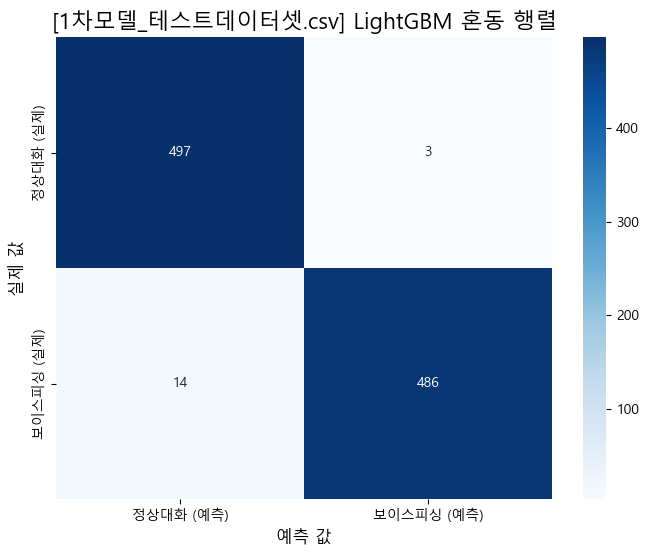


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,예 고객님 담당자 김성도 대리입니다.예지금 법무사님이 두분 배정되셨어요.네 네네 네...,1,1,99.22
1,6시 되가지고 전화 해봤습니다.예 예 그 앞전에 이면주 법무사님 영수증 확인되셨는데...,1,1,99.98
2,네 네 네 여보세요네 네어디에 계시는 겁니까 지금네?지금 어디 계시는 거예요방금 나...,1,1,99.99
3,여보세요예 여보세요. 네 감사과장 박철민 과장입니다.예아 OOO고객님 맞으시죠?예아...,1,1,99.99
4,신한은행 정부지원자금으로 마이너스 통장 계좌 통합 가능하십니다. 마이너스 통장 발급...,1,1,93.90
5,보니까 서면조사를 받으셔야 되고요 알겠습니다 그럼 말씀 드릴게요 계속 말씀드렸다시피...,1,1,99.96
6,서울중앙지검네 예 다름이 아니라 접수가 돼서 연락을 드렸고요. 예 통화 괜찮으신가요...,1,1,99.98
7,빨리 오세요 여기 강남청솔기숙 거예요 강남스타일 가요 가요 이제 신고 접수 확인 다...,1,1,92.69
8,예 예 아이고 통화해 보셨어요 님 아닌데요 어떤 것들이 님 저 지금 그쪽 확인해서 ...,1,1,99.81
9,네 고객님 아 근데 제가 보니까 같은데요. 우리은행 시간 많이 심어 놨습니다. 연락...,1,1,99.98


############################################################

############################################################
'시나리오통화테스트셋.csv' 파일에 대한 [LightGBM 부스팅 모델] 분석을 시작합니다.


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 6건
 - 보이스피싱 (1) 예측: 14건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       1.00      0.60      0.75        10
       보이스피싱       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



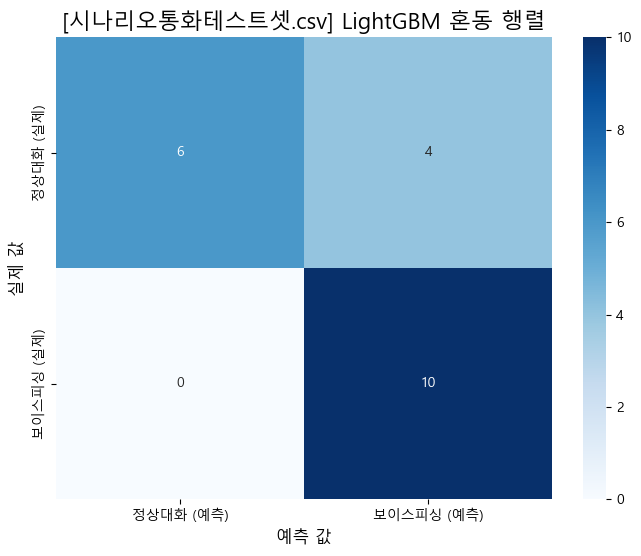


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,"네, 여보세요.\n네, 여보세요. 서울지방경찰청 사이퍼 범죄추사팀 박민선 승사관입니...",1,1,99.99
1,"고객님, 안녕하세요. 농협캐피탈입니다.\n고객님은 신용등급 상향 대상자로 선정되셔서...",1,1,99.99
2,"여보세요? 엄마 나야 나 지금 핸드폰 애 저 깨졌어, 친구 폰으로 연락했어.\n누구...",1,1,99.91
3,"네, 여보세요, 고객님, 안녕하세요, 로젠택배입니다, 고객님. 택배가 주소 의류로 ...",1,1,99.99
4,"네, 안녕하세요. 국민건강보험공단입니다. 고객님.\n작년 과오납 환급금이 47만원 ...",1,1,99.98
5,"네, 여보세요.\n네, 안녕하세요. 국민은행 상담센터입니다. 무엇을 도와드릴까요?\...",0,1,99.78
6,"엄마, 나 또 액정이 깨졌어, 지금 친구 폰으로 전화했어.\n더 깨졌어, 핸드폰을 ...",0,1,96.48
7,어제 주문한 물건이 계속 배송 중으로만 떠있어서요.\n운송장 번호 확인 가능하실까요...,0,1,99.65
8,세종내과입니다. 무엇을 도와드릴까요?\n혹시 그다음 주 수요일쯤 진료 예약 가능할까...,0,0,1.40
9,"안녕하세요. KB 국민카드 고객센터입니다. 무엇을 도와드릴까요?\n아니, 이번 달 ...",0,1,91.97


############################################################


In [52]:
# --- 2. 예측, 평가, 결과 출력 함수 정의 ---
def predict_and_display_results_single_model(
    csv_path: str, vectorizer, model, model_name: str = "모델"
):
    """
    주어진 CSV를 읽어 [Vectorizer -> 단일 모델] 순서로 예측을 수행하고,
    정답지가 있을 경우 성능 평가까지 수행하는 함수.
    """
    print("\n" + "#" * 60)
    print(f"'{csv_path}' 파일에 대한 [{model_name}] 분석을 시작합니다.")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: '{csv_path}'")
        return
    if "text" not in df.columns:
        print(f"'{csv_path}' 파일에 'text' 열이 없습니다.")
        return

    X_new_text = df["text"].astype(str)

    # 1. Vectorizer를 사용해 텍스트를 숫자 벡터로 변환
    X_new_vectorized = vectorizer.transform(X_new_text)

    # 2. 변환된 숫자 벡터를 모델에 넣어 예측 수행
    predictions = model.predict(X_new_vectorized)
    probabilities = model.predict_proba(X_new_vectorized)

    df["predicted_label"] = predictions
    df["phishing_probability"] = probabilities[:, 1] * 100

    # 예측 결과 요약 출력
    print("\n[ 예측 결과 요약 ]")
    prediction_counts = df["predicted_label"].value_counts()
    print(f" - 정상 대화 (0) 예측: {prediction_counts.get(0, 0)}건")
    print(f" - 보이스피싱 (1) 예측: {prediction_counts.get(1, 0)}건")

    if "is_phishing" in df.columns:
        y_true = df["is_phishing"]
        print("\n--- [ 모델 성능 평가 리포트 ] ---")
        print(
            classification_report(
                y_true, predictions, target_names=["정상대화", "보이스피싱"]
            )
        )

        # 혼동 행렬 (Confusion Matrix) 시각화
        cm = confusion_matrix(y_true, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["정상대화 (예측)", "보이스피싱 (예측)"],
            yticklabels=["정상대화 (실제)", "보이스피싱 (실제)"],
        )
        plt.title(f"[{csv_path}] LightGBM 혼동 행렬", fontsize=16)
        plt.ylabel("실제 값", fontsize=12)
        plt.xlabel("예측 값", fontsize=12)
        plt.show()  # 그래프 보여주기
    else:
        print("\n[알림] 정답(is_phishing) 열이 없어 성능 평가는 생략합니다.")

    print("\n[ 예측 결과 샘플 (상위 10개) ]")
    display_columns = ["text", "predicted_label", "phishing_probability"]
    if "is_phishing" in df.columns:
        display_columns.insert(1, "is_phishing")

    pd.options.display.float_format = "{:,.2f}".format
    display(df[display_columns].head(10))
    print("#" * 60)


# --- 3. 테스트할 파일 목록에 대해 분석 실행 ---
files_to_test = ["1차모델_테스트데이터셋.csv", "시나리오통화테스트셋.csv"]

for file_path in files_to_test:
    # 함수를 호출할 때 불러온 lgbm 모델과 모델 이름을 전달
    predict_and_display_results_single_model(
        file_path,
        loaded_vectorizer,
        loaded_lgbm_model,  # lgbm 모델 변수
        model_name="LightGBM 부스팅 모델",  # 그래프에 표시될 이름
    )

In [53]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호가 깨지는 문제 해결
plt.rcParams["axes.unicode_minus"] = False


class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        # 각 프로세스에서 최초 호출 시 Kiwi 객체를 한 번만 생성
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        # 텍스트 정제
        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        # 형태소 분석 및 필터링
        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 최종 클래스 정의 완료.")

초기 설정 및 최종 클래스 정의 완료.


In [55]:
# --- 1. 파일 경로 및 모델/Vectorizer 로딩 ---
print("저장된 Vectorizer와 RandomForest 모델을 불러옵니다...")

# Vectorizer 파일 경로
vectorizer_path = os.path.join("tfidf_vectorizer_6000_JJ.pkl")
# RandomForest 모델 파일 경로
rf_model_path = os.path.join("models", "random_forest_model_6000_JJ.pkl")

try:
    loaded_vectorizer = joblib.load(vectorizer_path)
    loaded_rf_model = joblib.load(rf_model_path)
    print(f" Vectorizer 로드 완료: {vectorizer_path}")
    print(f" RandomForest 모델 로드 완료: {rf_model_path}")

except Exception as e:
    print(f" 파일 로딩 중 에러 발생: {e}")

저장된 Vectorizer와 RandomForest 모델을 불러옵니다...
 Vectorizer 로드 완료: tfidf_vectorizer_6000_JJ.pkl
 RandomForest 모델 로드 완료: models\random_forest_model_6000_JJ.pkl


In [ ]:
# --- 2. 예측, 평가, 결과 출력 함수 정의 ---
def predict_and_display_results_single_model(
    csv_path: str, vectorizer, model, model_name: str = "모델"
):
    """
    주어진 CSV를 읽어 [Vectorizer -> 모델] 순서로 예측을 수행하고,
    정답지가 있을 경우 성능 평가까지 수행하는 함수.
    """
    print("\n" + "#" * 60)
    print(f"'{csv_path}' 파일에 대한 [{model_name}] 분석을 시작합니다.")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: '{csv_path}'")
        return
    if "text" not in df.columns:
        print(f"'{csv_path}' 파일에 'text' 열이 없습니다.")
        return

    X_new_text = df["text"].astype(str)

    # 1. Vectorizer를 사용해 텍스트를 숫자 벡터로 변환
    X_new_vectorized = vectorizer.transform(X_new_text)

    # 2. 변환된 숫자 벡터를 모델에 넣어 예측 수행
    predictions = model.predict(X_new_vectorized)
    probabilities = model.predict_proba(X_new_vectorized)

    df["predicted_label"] = predictions
    df["phishing_probability"] = probabilities[:, 1] * 100

    # 예측 결과 요약 출력
    print("\n[ 예측 결과 요약 ]")
    prediction_counts = df["predicted_label"].value_counts()
    print(f" - 정상 대화 (0) 예측: {prediction_counts.get(0, 0)}건")
    print(f" - 보이스피싱 (1) 예측: {prediction_counts.get(1, 0)}건")

    if "is_phishing" in df.columns:
        y_true = df["is_phishing"]
        print("\n--- [ 모델 성능 평가 리포트 ] ---")
        print(
            classification_report(
                y_true, predictions, target_names=["정상대화", "보이스피싱"]
            )
        )

        # 혼동 행렬 (Confusion Matrix) 시각화
        cm = confusion_matrix(y_true, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["정상대화 (예측)", "보이스피싱 (예측)"],
            yticklabels=["정상대화 (실제)", "보이스피싱 (실제)"],
        )
        plt.title(f"[{csv_path}] 랜덤포레스트 혼동 행렬", fontsize=16)
        plt.ylabel("실제 값", fontsize=12)
        plt.xlabel("예측 값", fontsize=12)
        plt.show()  # 그래프 보여주기
    else:
        print("\n[알림] 정답(is_phishing) 열이 없어 성능 평가는 생략합니다.")

    print("\n[ 예측 결과 샘플 (상위 10개) ]")
    display_columns = ["text", "predicted_label", "phishing_probability"]
    if "is_phishing" in df.columns:
        display_columns.insert(1, "is_phishing")

    pd.options.display.float_format = "{:,.2f}".format
    display(df[display_columns].head(10))
    print("#" * 60)


# --- 3. 테스트할 파일 목록에 대해 분석 실행 ---
files_to_test = ["1차모델_테스트데이터셋.csv", "시나리오통화테스트셋.csv"]

for file_path in files_to_test:
    # 함수를 호출할 때 불러온 lgbm 모델과 모델 이름을 전달
    predict_and_display_results_single_model(
        file_path,
        loaded_vectorizer,
        loaded_lf_model,  # lgbm 모델 변수
        model_name="랜덤포레스트 부스팅 모델",  # 그래프에 표시될 이름
    )


############################################################
'1차모델_테스트데이터셋.csv' 파일에 대한 [랜덤 포레스트 모델] 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 510건
 - 보이스피싱 (1) 예측: 490건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       0.98      1.00      0.99       500
       보이스피싱       1.00      0.98      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



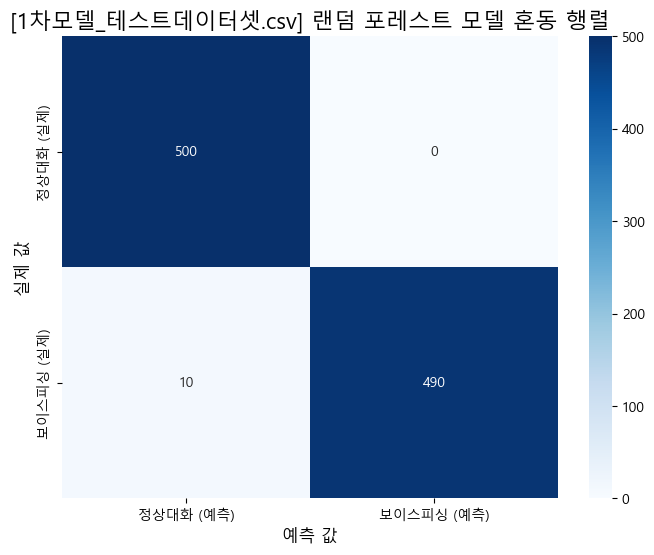


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,예 고객님 담당자 김성도 대리입니다.예지금 법무사님이 두분 배정되셨어요.네 네네 네...,1,1,76.67
1,6시 되가지고 전화 해봤습니다.예 예 그 앞전에 이면주 법무사님 영수증 확인되셨는데...,1,1,81.00
2,네 네 네 여보세요네 네어디에 계시는 겁니까 지금네?지금 어디 계시는 거예요방금 나...,1,1,93.00
3,여보세요예 여보세요. 네 감사과장 박철민 과장입니다.예아 OOO고객님 맞으시죠?예아...,1,1,92.00
4,신한은행 정부지원자금으로 마이너스 통장 계좌 통합 가능하십니다. 마이너스 통장 발급...,1,1,80.67
5,보니까 서면조사를 받으셔야 되고요 알겠습니다 그럼 말씀 드릴게요 계속 말씀드렸다시피...,1,1,70.00
6,서울중앙지검네 예 다름이 아니라 접수가 돼서 연락을 드렸고요. 예 통화 괜찮으신가요...,1,1,85.00
7,빨리 오세요 여기 강남청솔기숙 거예요 강남스타일 가요 가요 이제 신고 접수 확인 다...,1,1,65.17
8,예 예 아이고 통화해 보셨어요 님 아닌데요 어떤 것들이 님 저 지금 그쪽 확인해서 ...,1,1,82.50
9,네 고객님 아 근데 제가 보니까 같은데요. 우리은행 시간 많이 심어 놨습니다. 연락...,1,1,64.00


############################################################

############################################################
'시나리오통화테스트셋.csv' 파일에 대한 [랜덤 포레스트 모델] 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 8건
 - 보이스피싱 (1) 예측: 12건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       1.00      0.80      0.89        10
       보이스피싱       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



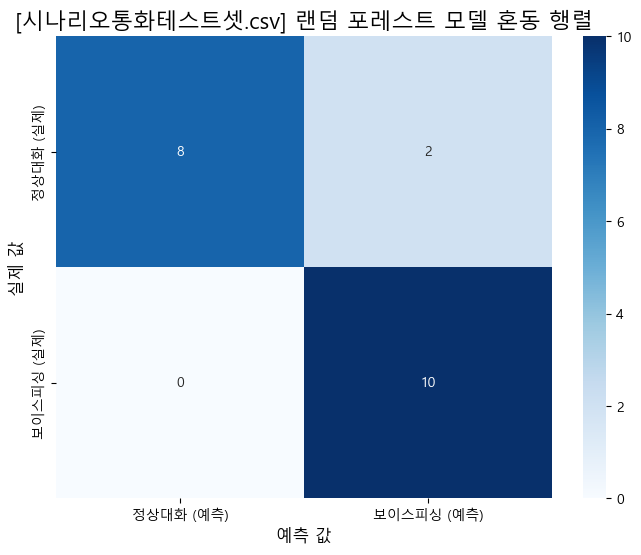


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,"네, 여보세요.\n네, 여보세요. 서울지방경찰청 사이퍼 범죄추사팀 박민선 승사관입니...",1,1,97.00
1,"고객님, 안녕하세요. 농협캐피탈입니다.\n고객님은 신용등급 상향 대상자로 선정되셔서...",1,1,86.00
2,"여보세요? 엄마 나야 나 지금 핸드폰 애 저 깨졌어, 친구 폰으로 연락했어.\n누구...",1,1,86.00
3,"네, 여보세요, 고객님, 안녕하세요, 로젠택배입니다, 고객님. 택배가 주소 의류로 ...",1,1,78.00
4,"네, 안녕하세요. 국민건강보험공단입니다. 고객님.\n작년 과오납 환급금이 47만원 ...",1,1,91.00
5,"네, 여보세요.\n네, 안녕하세요. 국민은행 상담센터입니다. 무엇을 도와드릴까요?\...",0,1,64.67
6,"엄마, 나 또 액정이 깨졌어, 지금 친구 폰으로 전화했어.\n더 깨졌어, 핸드폰을 ...",0,1,72.30
7,어제 주문한 물건이 계속 배송 중으로만 떠있어서요.\n운송장 번호 확인 가능하실까요...,0,0,32.00
8,세종내과입니다. 무엇을 도와드릴까요?\n혹시 그다음 주 수요일쯤 진료 예약 가능할까...,0,0,40.00
9,"안녕하세요. KB 국민카드 고객센터입니다. 무엇을 도와드릴까요?\n아니, 이번 달 ...",0,0,48.00


############################################################


In [57]:
# --- 2. 예측, 평가, 결과 출력 함수 정의 ---
def predict_and_display_results_single_model(
    csv_path: str, vectorizer, model, model_name: str = "모델"
):
    print("\n" + "#" * 60)
    print(f"'{csv_path}' 파일에 대한 [{model_name}] 분석을 시작합니다.")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: '{csv_path}'")
        return
    if "text" not in df.columns:
        print(f"'{csv_path}' 파일에 'text' 열이 없습니다.")
        return

    X_new_text = df["text"].astype(str)

    # 1. Vectorizer를 사용해 텍스트를 숫자 벡터로 변환
    X_new_vectorized = vectorizer.transform(X_new_text)

    # 2. 변환된 숫자 벡터를 모델에 넣어 예측 수행
    predictions = model.predict(X_new_vectorized)
    probabilities = model.predict_proba(X_new_vectorized)

    df["predicted_label"] = predictions
    df["phishing_probability"] = probabilities[:, 1] * 100

    # 예측 결과 요약 출력
    print("\n[ 예측 결과 요약 ]")
    prediction_counts = df["predicted_label"].value_counts()
    print(f" - 정상 대화 (0) 예측: {prediction_counts.get(0, 0)}건")
    print(f" - 보이스피싱 (1) 예측: {prediction_counts.get(1, 0)}건")

    if "is_phishing" in df.columns:
        y_true = df["is_phishing"]
        print("\n--- [ 모델 성능 평가 리포트 ] ---")
        print(
            classification_report(
                y_true, predictions, target_names=["정상대화", "보이스피싱"]
            )
        )
        cm = confusion_matrix(y_true, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["정상대화 (예측)", "보이스피싱 (예측)"],
            yticklabels=["정상대화 (실제)", "보이스피싱 (실제)"],
        )

        plt.title(f"[{csv_path}] {model_name} 혼동 행렬", fontsize=16)
        plt.ylabel("실제 값", fontsize=12)
        plt.xlabel("예측 값", fontsize=12)
        plt.show()
    else:
        print("\n[알림] 정답(is_phishing) 열이 없어 성능 평가는 생략합니다.")

    print("\n[ 예측 결과 샘플 (상위 10개) ]")
    display_columns = ["text", "predicted_label", "phishing_probability"]
    if "is_phishing" in df.columns:
        display_columns.insert(1, "is_phishing")

    pd.options.display.float_format = "{:,.2f}".format
    display(df[display_columns].head(10))
    print("#" * 60)


# --- 3. 테스트할 파일 목록에 대해 분석 실행 ---
files_to_test = ["1차모델_테스트데이터셋.csv", "시나리오통화테스트셋.csv"]

for file_path in files_to_test:
    predict_and_display_results_single_model(
        file_path,
        loaded_vectorizer,
        loaded_rf_model,
        model_name="랜덤 포레스트 모델",  
    )

In [59]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호가 깨지는 문제 해결
plt.rcParams["axes.unicode_minus"] = False


class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        # 각 프로세스에서 최초 호출 시 Kiwi 객체를 한 번만 생성
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        # 텍스트 정제
        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        # 형태소 분석 및 필터링
        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 최종 클래스 정의 완료.")

초기 설정 및 최종 클래스 정의 완료.


In [60]:
# --- 1. 파일 경로 및 모델/Vectorizer 로딩 ---
print("저장된 Vectorizer와 Logistic Regression 모델을 불러옵니다...")

# Vectorizer 파일 경로
vectorizer_path = os.path.join("tfidf_vectorizer_6000_JJ.pkl")
# 로지스틱 회귀 모델 파일 경로
lr_model_path = os.path.join("models", "logistic_regression_model_6000_JJ.pkl")

try:
    loaded_vectorizer = joblib.load(vectorizer_path)
    loaded_lr_model = joblib.load(lr_model_path)
    print(f"Vectorizer 로드 완료: {vectorizer_path}")
    print(f"Logistic Regression 모델 로드 완료: {lr_model_path}")

except Exception as e:
    print(f"파일 로딩 중 에러 발생: {e}")

저장된 Vectorizer와 Logistic Regression 모델을 불러옵니다...
Vectorizer 로드 완료: tfidf_vectorizer_6000_JJ.pkl
Logistic Regression 모델 로드 완료: models\logistic_regression_model_6000_JJ.pkl



############################################################
'1차모델_테스트데이터셋.csv' 파일에 대한 [로지스틱 회귀 모델] 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 505건
 - 보이스피싱 (1) 예측: 495건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       0.99      1.00      1.00       500
       보이스피싱       1.00      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000



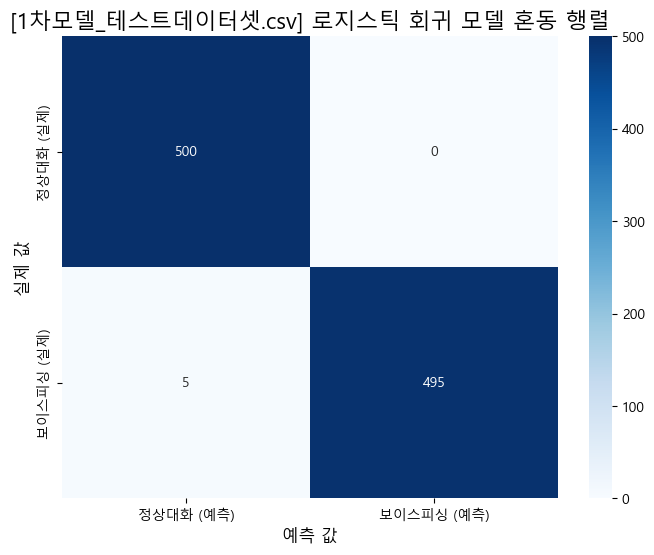


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,예 고객님 담당자 김성도 대리입니다.예지금 법무사님이 두분 배정되셨어요.네 네네 네...,1,1,78.60
1,6시 되가지고 전화 해봤습니다.예 예 그 앞전에 이면주 법무사님 영수증 확인되셨는데...,1,1,75.66
2,네 네 네 여보세요네 네어디에 계시는 겁니까 지금네?지금 어디 계시는 거예요방금 나...,1,1,98.06
3,여보세요예 여보세요. 네 감사과장 박철민 과장입니다.예아 OOO고객님 맞으시죠?예아...,1,1,99.31
4,신한은행 정부지원자금으로 마이너스 통장 계좌 통합 가능하십니다. 마이너스 통장 발급...,1,1,86.11
5,보니까 서면조사를 받으셔야 되고요 알겠습니다 그럼 말씀 드릴게요 계속 말씀드렸다시피...,1,1,82.95
6,서울중앙지검네 예 다름이 아니라 접수가 돼서 연락을 드렸고요. 예 통화 괜찮으신가요...,1,1,92.11
7,빨리 오세요 여기 강남청솔기숙 거예요 강남스타일 가요 가요 이제 신고 접수 확인 다...,1,1,53.05
8,예 예 아이고 통화해 보셨어요 님 아닌데요 어떤 것들이 님 저 지금 그쪽 확인해서 ...,1,1,84.11
9,네 고객님 아 근데 제가 보니까 같은데요. 우리은행 시간 많이 심어 놨습니다. 연락...,1,1,95.90


############################################################

############################################################
'시나리오통화테스트셋.csv' 파일에 대한 [로지스틱 회귀 모델] 분석을 시작합니다.

[ 예측 결과 요약 ]
 - 정상 대화 (0) 예측: 7건
 - 보이스피싱 (1) 예측: 13건

--- [ 모델 성능 평가 리포트 ] ---
              precision    recall  f1-score   support

        정상대화       1.00      0.70      0.82        10
       보이스피싱       0.77      1.00      0.87        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



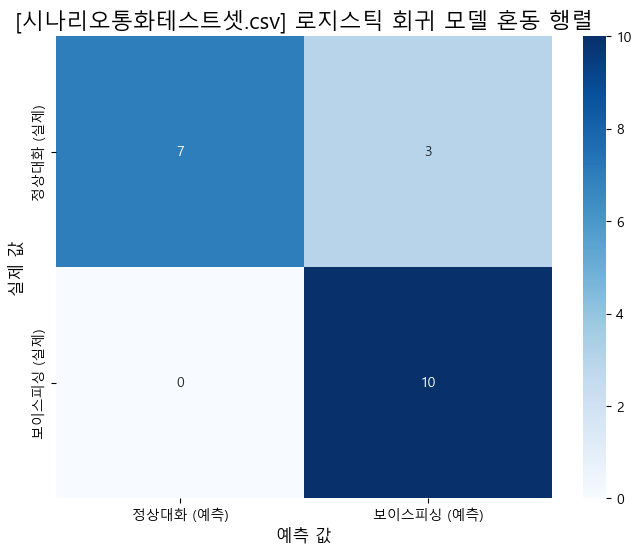


[ 예측 결과 샘플 (상위 10개) ]


,text,is_phishing,predicted_label,phishing_probability
0,"네, 여보세요.\n네, 여보세요. 서울지방경찰청 사이퍼 범죄추사팀 박민선 승사관입니...",1,1,99.35
1,"고객님, 안녕하세요. 농협캐피탈입니다.\n고객님은 신용등급 상향 대상자로 선정되셔서...",1,1,99.49
2,"여보세요? 엄마 나야 나 지금 핸드폰 애 저 깨졌어, 친구 폰으로 연락했어.\n누구...",1,1,89.88
3,"네, 여보세요, 고객님, 안녕하세요, 로젠택배입니다, 고객님. 택배가 주소 의류로 ...",1,1,98.58
4,"네, 안녕하세요. 국민건강보험공단입니다. 고객님.\n작년 과오납 환급금이 47만원 ...",1,1,96.29
5,"네, 여보세요.\n네, 안녕하세요. 국민은행 상담센터입니다. 무엇을 도와드릴까요?\...",0,1,80.83
6,"엄마, 나 또 액정이 깨졌어, 지금 친구 폰으로 전화했어.\n더 깨졌어, 핸드폰을 ...",0,1,71.94
7,어제 주문한 물건이 계속 배송 중으로만 떠있어서요.\n운송장 번호 확인 가능하실까요...,0,0,34.35
8,세종내과입니다. 무엇을 도와드릴까요?\n혹시 그다음 주 수요일쯤 진료 예약 가능할까...,0,0,36.67
9,"안녕하세요. KB 국민카드 고객센터입니다. 무엇을 도와드릴까요?\n아니, 이번 달 ...",0,1,59.22


############################################################


In [61]:
# --- 2. 예측, 평가, 결과 출력 함수 정의 ---
def predict_and_display_results_single_model(
    csv_path: str, vectorizer, model, model_name: str = "모델"
):
    """
    주어진 CSV를 읽어 [Vectorizer -> 단일 모델] 순서로 예측을 수행하고,
    정답지가 있을 경우 성능 평가까지 수행하는 함수.
    """
    print("\n" + "#" * 60)
    print(f"'{csv_path}' 파일에 대한 [{model_name}] 분석을 시작합니다.")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: '{csv_path}'")
        return
    if "text" not in df.columns:
        print(f"'{csv_path}' 파일에 'text' 열이 없습니다.")
        return

    X_new_text = df["text"].astype(str)

    # 1. Vectorizer를 사용해 텍스트를 숫자 벡터로 변환
    X_new_vectorized = vectorizer.transform(X_new_text)

    # 2. 변환된 숫자 벡터를 모델에 넣어 예측 수행
    predictions = model.predict(X_new_vectorized)
    probabilities = model.predict_proba(X_new_vectorized)

    # 예측 결과를 데이터프레임에 추가
    df["predicted_label"] = predictions
    df["phishing_probability"] = probabilities[:, 1] * 100

    # 예측 결과 요약 출력
    print("\n[ 예측 결과 요약 ]")
    prediction_counts = df["predicted_label"].value_counts()
    print(f" - 정상 대화 (0) 예측: {prediction_counts.get(0, 0)}건")
    print(f" - 보이스피싱 (1) 예측: {prediction_counts.get(1, 0)}건")

    # 'is_phishing' 정답 열이 있을 경우에만 평가 수행
    if "is_phishing" in df.columns:
        y_true = df["is_phishing"]
        print("\n--- [ 모델 성능 평가 리포트 ] ---")
        print(
            classification_report(
                y_true, predictions, target_names=["정상대화", "보이스피싱"]
            )
        )

        # 혼동 행렬 (Confusion Matrix) 시각화
        cm = confusion_matrix(y_true, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["정상대화 (예측)", "보이스피싱 (예측)"],
            yticklabels=["정상대화 (실제)", "보이스피싱 (실제)"],
        )
        plt.title(f"[{csv_path}] {model_name} 혼동 행렬", fontsize=16)
        plt.ylabel("실제 값", fontsize=12)
        plt.xlabel("예측 값", fontsize=12)
        plt.show()
    else:
        print("\n[알림] 정답(is_phishing) 열이 없어 성능 평가는 생략합니다.")

    # 예측 결과 샘플 출력 (상위 10개)
    print("\n[ 예측 결과 샘플 (상위 10개) ]")
    display_columns = ["text", "predicted_label", "phishing_probability"]
    if "is_phishing" in df.columns:
        display_columns.insert(1, "is_phishing")

    pd.options.display.float_format = "{:,.2f}".format
    # display() 함수는 주피터 환경에서 데이터프레임을 더 예쁘게 출력해줌
    display(df[display_columns].head(10))
    print("#" * 60)


# --- 3. 테스트할 파일 목록에 대해 분석 실행 ---
files_to_test = ["1차모델_테스트데이터셋.csv", "시나리오통화테스트셋.csv"]

for file_path in files_to_test:
    predict_and_display_results_single_model(
        file_path,
        loaded_vectorizer,
        loaded_lr_model,  
        model_name="로지스틱 회귀 모델", 
    )